### Import

In [ ]:
import os; import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import numpy as np; import matplotlib.pyplot as plt
import gurobipy as gp; from gurobipy import GRB
from itertools import product; from tqdm import tqdm
import importlib
import functions_utils; import functions_data
import functions_optimize; import functions_eval
importlib.reload(functions_data); importlib.reload(functions_optimize)
importlib.reload(functions_eval); importlib.reload(functions_utils)
from functions_utils import *; from functions_data import *
from functions_optimize import *; from functions_eval import *
import time

S = 100
LEVEL = "high"
SEED = 1

generation_data, I, T = load_generation_data(date_filter="2022-07-18")
R, P_RT, K, K0, _, _, CRATE, DRATE = load_parameters(I, T, generation_data, S, LEVEL, SEED)
P_DA, P_PN = load_price_data(P_RT)
INEFF = 0.9

MYP = np.zeros((I, T, S)) ; MYM = np.zeros((I, T, S)) ; MZC = np.zeros((I, T, S)) ; MZD = np.zeros((I, T, S)) ; MDP = np.zeros((I, T, S)) ; MDM = np.zeros((I, T, S))  
R_max = np.zeros((I, T)) ; R_min = np.zeros((I, T)); R_avg = np.zeros((I, T))
for i, t in product(range(I), range(T)):
    R_max[i, t] = np.max(R[i, t, :])
    R_min[i, t] = np.min(R[i, t, :])
    R_avg[i, t] = np.mean(R[i, t, :])
    
    for s in range(S): 
        MYP[i, t, s] = MDP[i, t, s] = R[i, t, s] + INEFF * DRATE[i]
        MZC[i, t, s] = min((1 / INEFF) * CRATE[i], R[i, t, s])
        MZD[i, t, s] = INEFF * DRATE[i]
        MYM[i, t, s] = MDM[i, t, s] = R_max[i, t] + INEFF * DRATE[i]
        # MYM[i, t, s] = MDM[i, t, s] = R[i, t, s] + INEFF * DRATE[i]

✅ 총 10개 파일을 불러왔습니다: 1033.csv, 1818.csv, 2502.csv, 2503.csv, 2634.csv, 2698.csv, 2816.csv, 545.csv, 665.csv, 690.csv
📊 데이터 Shape: I=10, T=24, S=200
✅ 시뮬레이션 초기화 완료: S=200, Randomness='high', Random Seed=1, M1=3743.07, M2=9869.63
   - 개별 K 값: [200. 200. 400. 600. 100. 600. 300. 200. 300. 200.]


### Individual Optimization (original)

In [167]:
m1 = gp.Model("individual")
m1.setParam("MIPGap", 1e-5)

x_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x")
yp_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp") ; ym_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")
z_ind = m1.addVars(I, T + 1, S, vtype=GRB.CONTINUOUS, lb=0, name="z")
zc_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zc") ; zd_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zd")

# LDR 계수 변수들
zc0_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc0") ; zc1_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc1") ; zc2_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc2")
zd0_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd0") ; zd1_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd1") ; zd2_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd2")

# # Big-M 관련 변수들    
# phi1_ind = m1.addVars(I, T, S, vtype=GRB.BINARY, name="phi1") ; phi2_ind = m1.addVars(I, T, S, vtype=GRB.BINARY, name="phi2") ; phi3_ind = m1.addVars(I, T, S, vtype=GRB.BINARY, name="phi3")

m1.update()

obj = (gp.quicksum(P_DA[t] * x_ind[i, t] for i in range(I) for t in range(T)) + 
       gp.quicksum((1/S) * (P_RT[t, s] * yp_ind[i, t, s] - P_PN[t, s] * ym_ind[i, t, s]) for i in range(I) for t in range(T) for s in range(S)))
m1.setObjective(obj, GRB.MAXIMIZE)

for i, t, s in product(range(I), range(T), range(S)):
    m1.addConstr(R[i, t, s] - x_ind[i, t] == yp_ind[i, t, s] - ym_ind[i, t, s] + zc_ind[i, t, s] - zd_ind[i, t, s])
    m1.addConstr(R[i, t, s] + zd_ind[i, t, s] >= yp_ind[i, t, s] + zc_ind[i, t, s])
    m1.addConstr(zd_ind[i, t, s]/INEFF <= z_ind[i, t, s])
    m1.addConstr(zd_ind[i, t, s]/INEFF <= DRATE[i])
    m1.addConstr(zc_ind[i, t, s]*INEFF <= K[i] - z_ind[i, t, s])
    m1.addConstr(zc_ind[i, t, s]*INEFF <= CRATE[i])
    m1.addConstr(z_ind[i, t, s] <= K[i])
    m1.addConstr(z_ind[i, t + 1, s] == z_ind[i, t, s] + INEFF * zc_ind[i, t, s] - zd_ind[i, t, s] / INEFF)

for i, s in product(range(I), range(S)): m1.addConstr(z_ind[i, 0, s] == K0[i])

for i, t, s in product(range(I), range(T), range(S)):
    m1.addConstr(zc_ind[i, t, s] == zc0_ind[i, t] + zc1_ind[i, t] * R[i, t, s] + zc2_ind[i, t] * (P_RT[t, s] - P_DA[t]))
    m1.addConstr(zd_ind[i, t, s] == zd0_ind[i, t] + zd1_ind[i, t] * R[i, t, s] + zd2_ind[i, t] * (P_RT[t, s] - P_DA[t]))

# for i, t, s in product(range(I), range(T), range(S)):        
#     m1.addConstr(ym_ind[i, t, s] <= MYM[i, t, s] * phi1_ind[i, t, s]) ; m1.addConstr(zc_ind[i, t, s] <= MZC[i, t, s] * (1 - phi1_ind[i, t, s]))
#     m1.addConstr(zc_ind[i, t, s] <= MZC[i, t, s] * phi2_ind[i, t, s]) ; m1.addConstr(zd_ind[i, t, s] <= MZD[i, t, s] * (1 - phi2_ind[i, t, s]))

m1.optimize()

if m1.status == GRB.OPTIMAL:
    x_ind = np.array([[x_ind[i, t].X for t in range(T)] for i in range(I)])
    yp_ind = np.array([[[yp_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; ym_ind = np.array([[[ym_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    zc_ind = np.array([[[zc_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; zd_ind = np.array([[[zd_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    z_ind = np.array([[[z_ind[i, t, s].X for s in range(S)] for t in range(T+1)] for i in range(I)]) ; original_objval = m1.objVal
    # phi1_ind = np.array([[[phi1_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; phi2_ind = np.array([[[phi2_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    
    zc0_ind = np.array([[zc0_ind[i, t].X for t in range(T)] for i in range(I)]) ; zc1_ind = np.array([[zc1_ind[i, t].X for t in range(T)] for i in range(I)]) ; zc2_ind = np.array([[zc2_ind[i, t].X for t in range(T)] for i in range(I)])
    zd0_ind = np.array([[zd0_ind[i, t].X for t in range(T)] for i in range(I)]) ; zd1_ind = np.array([[zd1_ind[i, t].X for t in range(T)] for i in range(I)]) ; zd2_ind = np.array([[zd2_ind[i, t].X for t in range(T)] for i in range(I)])
    OBJ_IND = m1.objVal

Set parameter MIPGap to value 1e-05
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
MIPGap  1e-05

Optimize a model with 482000 rows, 243680 columns and 1262800 nonzeros
Model fingerprint: 0x1e9b61ea
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [2e-02, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 274205 rows and 96863 columns
Presolve time: 0.87s
Presolved: 80557 rows, 278897 columns, 1348226 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.15s

Barrier statistics:
 Free vars  : 44408
 AA' NZ     : 8.789e+05
 Factor NZ  : 2.662e+06 (roughly 170 MB of memory)
 Factor Ops : 1.342e+08 (less than 1 second per iteration)
 Th

In [168]:
header = (f"{'t':>2} | {'R':>8} {'x':>8} {'y+':>8} {'y-':>8} {'zc':>8} {'zd':>8} {'z':>8}\n" + "-" * 70)
print("\n[Individual]") ; print(header)
for t in range(7, 22):
    # R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_ind[:, t].sum()
    # yp_avg = np.mean([yp_ind[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_ind[:, t, s].sum() for s in range(S)])
    # zc_avg = np.mean([zc_ind[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_ind[:, t, s].sum() for s in range(S)]) 
    # z_avg = np.mean([z_ind[:, t, s].sum() for s in range(S)])

    i=1
    R_avg = np.mean([R[i, t, s] for s in range(S)]) ; x_sum = x_ind[i, t]
    yp_avg = np.mean([yp_ind[i, t, s] for s in range(S)]) ; ym_avg = np.mean([ym_ind[i, t, s] for s in range(S)])
    zc_avg = np.mean([zc_ind[i, t, s] for s in range(S)]) ; zd_avg = np.mean([zd_ind[i, t, s] for s in range(S)]) 
    z_avg = np.mean([z_ind[i, t, s] for s in range(S)])

    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")


[Individual]
 t |        R        x       y+       y-       zc       zd        z
----------------------------------------------------------------------
 7 |    72.30    14.81    40.46     1.30    18.34     0.00     5.88
 8 |   115.42    53.29    41.18    10.17    31.12     0.00    22.38
 9 |   177.46   130.49    56.19    18.54     9.31     0.00    50.39
10 |   177.38   141.43    52.67    19.99     4.58     1.30    58.77
11 |   218.27   155.32    77.15    19.82     5.62     0.00    61.45
12 |   229.11   175.85    73.99    20.38     0.25     0.60    66.51
13 |   455.78     0.00   500.78     0.00     0.00    45.00    66.06
14 |   525.44   118.59   410.08     0.00     0.00     3.23    16.06
15 |   497.90   505.51    89.66   101.85     4.59     0.00    12.47
16 |   158.62   139.93    39.76    24.20     3.13     0.00    16.60
17 |   185.68   144.20    60.04    18.57     2.34     2.33    19.42
18 |   248.90   179.70    93.76    22.25     4.05     6.37    18.94
19 |   105.53    75.77    40.37

In [ ]:
for i, t, s in product(range(I), range(T), range(S)):
    if zc_ind[i, t, s] * zd_ind[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, zc={zc_ind[i, t, s]}, zd={zd_ind[i, t, s]}")
    # if zc_ind[i, t, s] * ym_ind[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_ind[i, t, s]}, ym={ym_ind[i, t, s]}")

i=1, t=10, s=0, zc=6.91104432973499, zd=1.6262804579628494
i=1, t=10, s=1, zc=6.972171519336243, zd=2.470609911964649
i=1, t=10, s=2, zc=2.7215466082759785, zd=1.7091238510604203
i=1, t=10, s=3, zc=3.935568070225667, zd=0.7012910957032634
i=1, t=10, s=4, zc=5.527570822803895, zd=0.8295801354033667
i=1, t=10, s=5, zc=3.7397591423123773, zd=1.4967074464722483
i=1, t=10, s=6, zc=4.992565180116742, zd=2.712781809486388
i=1, t=10, s=7, zc=5.0256555617926955, zd=0.5129742190426896
i=1, t=10, s=8, zc=7.80371768827944, zd=1.4378953919567516
i=1, t=10, s=9, zc=6.8127626355785385, zd=0.966410336105584
i=1, t=10, s=10, zc=6.367290069316468, zd=2.1707360724228666
i=1, t=10, s=11, zc=0.5337750603189646, zd=2.255415660162047
i=1, t=10, s=12, zc=1.5117939038591282, zd=1.1866707702966668
i=1, t=10, s=13, zc=8.272894667574425, zd=0.5735550868155794
i=1, t=10, s=14, zc=7.091699688242909, zd=0.18403632830906425
i=1, t=10, s=15, zc=1.6619124843029167, zd=0.5477777560607127
i=1, t=10, s=16, zc=0.6108389607

### Individual Optimization (1)

In [159]:
m1 = gp.Model("individual_deltaZ")
m1.setParam("MIPGap", 1e-5)

# ---------------------------------------------------------
# Main decision variables
# ---------------------------------------------------------

# x, yp, ym (same as before)
x_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x")
yp_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp")
ym_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")

# Storage
z_ind  = m1.addVars(I, T+1, S, vtype=GRB.CONTINUOUS, lb=0, name="z")
zc_ind = m1.addVars(I, T,   S, vtype=GRB.CONTINUOUS, lb=0, name="zc")   # free scenario-wise
zd_ind = m1.addVars(I, T,   S, vtype=GRB.CONTINUOUS, lb=0, name="zd")   # free scenario-wise

# Δz (scenario-wise net)
dz_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=-GRB.INFINITY, name="dz")

# ---------------------------------------------------------
# LDR variables ONLY for Δz
# ---------------------------------------------------------
dz0_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz0")
dz1_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz1")
dz2_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz2")

m1.update()

# ---------------------------------------------------------
# Objective
# ---------------------------------------------------------
obj = (
    gp.quicksum(P_DA[t] * x_ind[i, t] for i in range(I) for t in range(T))
    + gp.quicksum((1/S)*(
        P_RT[t, s]*yp_ind[i, t, s] -
        P_PN[t, s]*ym_ind[i, t, s])
        for i in range(I) for t in range(T) for s in range(S))
)
m1.setObjective(obj, GRB.MAXIMIZE)

# ---------------------------------------------------------
# Constraints
# ---------------------------------------------------------
for i, t, s in product(range(I), range(T), range(S)):

    # (0) LDR defines dz (not zc, zd)
    m1.addConstr(
        dz_ind[i,t,s] ==
        dz0_ind[i,t]
        + dz1_ind[i,t]*R[i,t,s]
        + dz2_ind[i,t]*(P_RT[t,s] - P_DA[t])
    )

    # (1) Define relation between dz and (zc,zd)
    m1.addConstr(dz_ind[i,t,s] == zc_ind[i,t,s] - zd_ind[i,t,s])

    # (2) Power balance
    m1.addConstr(
        R[i,t,s] - x_ind[i,t] ==
        yp_ind[i,t,s] - ym_ind[i,t,s] + dz_ind[i,t,s]
    )

    # (3) Storage SOC transition (inefficiency included)
    m1.addConstr(
        z_ind[i,t+1,s] ==
        z_ind[i,t,s] + INEFF*zc_ind[i,t,s] - zd_ind[i,t,s]/INEFF
    )

    # (4) SOC bounds
    m1.addConstr(z_ind[i,t+1,s] <= K[i])

    # (5) Discharge limits
    m1.addConstr(zd_ind[i,t,s] / INEFF <= z_ind[i,t,s])   # SOC
    m1.addConstr(zd_ind[i,t,s] / INEFF <= DRATE[i])       # rate

    # (6) Charge limits
    m1.addConstr(zc_ind[i,t,s] * INEFF <= K[i] - z_ind[i,t,s]) # SOC
    m1.addConstr(zc_ind[i,t,s] * INEFF <= CRATE[i])            # rate

# initial SOC
for i, s in product(range(I), range(S)):
    m1.addConstr(z_ind[i,0,s] == K0[i])

m1.optimize()

# ---------------------------------------------------------
# Check simultaneous charge/discharge
# ---------------------------------------------------------
if m1.status == GRB.OPTIMAL:
    zc_sol = np.array([[[zc_ind[i,t,s].X for s in range(S)] for t in range(T)] for i in range(I)])
    zd_sol = np.array([[[zd_ind[i,t,s].X for s in range(S)] for t in range(T)] for i in range(I)])
    dz_sol = np.array([[[dz_ind[i,t,s].X for s in range(S)] for t in range(T)] for i in range(I)])

    print("---- Checking simultaneous C/D ----")
    for i in range(I):
        for t in range(T):
            for s in range(S):
                if zc_sol[i,t,s] > 1e-6 and zd_sol[i,t,s] > 1e-6:
                    print(f"[WARNING] Simultaneous C/D at (i={i},t={t},s={s})  "
                          f"zc={zc_sol[i,t,s]:.4f}, zd={zd_sol[i,t,s]:.4f}, dz={dz_sol[i,t,s]:.4f}")


Set parameter MIPGap to value 1e-05
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
MIPGap  1e-05

Optimize a model with 434000 rows, 290960 columns and 1040400 nonzeros
Model fingerprint: 0x7d668726
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [2e-02, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 245958 rows and 100024 columns
Presolve time: 0.88s
Presolved: 188042 rows, 190936 columns, 860522 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.09s

Barrier statistics:
 Dense cols : 852
 AA' NZ     : 1.176e+06
 Factor NZ  : 4.548e+06 (roughly 200 MB of memory)
 Factor Ops : 1.406e+08 (less than 1 second per iteration)
 Thr

### Individual Optimization (2)

In [170]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from itertools import product

m1 = gp.Model("individual_delta_only")
m1.setParam("MIPGap", 1e-5)

# -----------------------------
# Variables
# -----------------------------
# Day-ahead schedule
x_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x")

# Real-time up/down deviations
yp_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp")
ym_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")

# SOC (scenario-wise)
z_ind = m1.addVars(I, T+1, S, vtype=GRB.CONTINUOUS, lb=0, name="z")

# Net storage power (charging + / discharging -), scenario-wise
dz_ind = m1.addVars(I, T, S, vtype=GRB.CONTINUOUS,
                    lb=-GRB.INFINITY, name="dz")

# LDR coefficients for Δz (only these are policy variables)
dz0_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz0")
dz1_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz1")
dz2_ind = m1.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz2")

m1.update()

# -----------------------------
# Objective
# -----------------------------
obj = (
    gp.quicksum(P_DA[t] * x_ind[i, t] for i in range(I) for t in range(T))
    + gp.quicksum(
        (1 / S)
        * (P_RT[t, s] * yp_ind[i, t, s] - P_PN[t, s] * ym_ind[i, t, s])
        for i in range(I) for t in range(T) for s in range(S)
    )
)
m1.setObjective(obj, GRB.MAXIMIZE)

# -----------------------------
# Constraints
# -----------------------------
for i, t, s in product(range(I), range(T), range(S)):

    # (1) LDR: Δz as affine function of (R, price spread)
    m1.addConstr(
        dz_ind[i, t, s]
        == dz0_ind[i, t]
        + dz1_ind[i, t] * R[i, t, s]
        + dz2_ind[i, t] * (P_RT[t, s] - P_DA[t])
    )

    # (2) Power balance with net storage Δz
    m1.addConstr(
        R[i, t, s] - x_ind[i, t]
        == yp_ind[i, t, s] - ym_ind[i, t, s] + dz_ind[i, t, s]
    )

    # (3) SOC transition (lossless storage)
    m1.addConstr(
        z_ind[i, t + 1, s] == z_ind[i, t, s] + dz_ind[i, t, s]
    )

    # (4) SOC upper bound
    m1.addConstr(z_ind[i, t + 1, s] <= K[i])

    # (5) Discharge limits (Δz < 0 구간에서만 active)
    m1.addConstr(-dz_ind[i, t, s] <= z_ind[i, t, s])   # cannot discharge more than SOC
    m1.addConstr(-dz_ind[i, t, s] <= DRATE[i])         # discharge power limit

    # (6) Charge limits (Δz > 0 구간에서만 active)
    m1.addConstr(dz_ind[i, t, s] <= K[i] - z_ind[i, t, s])  # cannot exceed capacity
    m1.addConstr(dz_ind[i, t, s] <= CRATE[i])               # charge power limit

# Initial SOC
for i, s in product(range(I), range(S)):
    m1.addConstr(z_ind[i, 0, s] == K0[i])

m1.optimize()

# -----------------------------
# Extract solution & (optional) reconstruct zc, zd
# -----------------------------
if m1.status == GRB.OPTIMAL:
    x_ind = np.array([[x_ind[i, t].X for t in range(T)] for i in range(I)])
    yp_ind = np.array(
        [[[yp_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]
    )
    ym_ind = np.array(
        [[[ym_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]
    )
    dz_ind = np.array(
        [[[dz_ind[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]
    )
    z_ind = np.array(
        [[[z_ind[i, t, s].X for s in range(S)] for t in range(T + 1)] for i in range(I)]
    )
    dz0_ind = np.array([[dz0_ind[i, t].X for t in range(T)] for i in range(I)])
    dz1_ind = np.array([[dz1_ind[i, t].X for t in range(T)] for i in range(I)])
    dz2_ind = np.array([[dz2_ind[i, t].X for t in range(T)] for i in range(I)])
    OBJ_IND = m1.objVal

    # 필요하면 사후에 (lossless 가정하에서) zc, zd 복원 가능:
    # zc = max(dz, 0), zd = max(-dz, 0)
    zc_ind = np.maximum(dz_ind, 0.0)
    zd_ind = np.maximum(-dz_ind, 0.0)


Set parameter MIPGap to value 1e-05
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
MIPGap  1e-05

Optimize a model with 386000 rows, 194960 columns and 848400 nonzeros
Model fingerprint: 0xbe66e1a4
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [2e-02, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 201928 rows and 11964 columns
Presolve time: 0.61s
Presolved: 33326 rows, 227456 columns, 681182 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.06s

Barrier statistics:
 Free vars  : 32474
 AA' NZ     : 3.150e+05
 Factor NZ  : 1.097e+06 (roughly 110 MB of memory)
 Factor Ops : 5.080e+07 (less than 1 second per iteration)
 Thre

In [171]:
header = (f"{'t':>2} | {'R':>8} {'x':>8} {'y+':>8} {'y-':>8} {'zc':>8} {'zd':>8} {'z':>8}\n" + "-" * 70)
print("\n[Individual]") ; print(header)
for t in range(7, 22):
    # R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_ind[:, t].sum()
    # yp_avg = np.mean([yp_ind[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_ind[:, t, s].sum() for s in range(S)])
    # zc_avg = np.mean([zc_ind[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_ind[:, t, s].sum() for s in range(S)]) 
    # z_avg = np.mean([z_ind[:, t, s].sum() for s in range(S)])

    i=1
    R_avg = np.mean([R[i, t, s] for s in range(S)]) ; x_sum = x_ind[i, t]
    yp_avg = np.mean([yp_ind[i, t, s] for s in range(S)]) ; ym_avg = np.mean([ym_ind[i, t, s] for s in range(S)])
    zc_avg = np.mean([zc_ind[i, t, s] for s in range(S)]) ; zd_avg = np.mean([zd_ind[i, t, s] for s in range(S)]) 
    z_avg = np.mean([z_ind[i, t, s] for s in range(S)])

    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")


[Individual]
 t |        R        x       y+       y-       zc       zd        z
----------------------------------------------------------------------
 7 |    72.30     0.00    34.07     1.32    39.56     0.00     6.53
 8 |   115.42    34.26    43.90     9.99    47.25     0.00    46.09
 9 |   177.46   102.23    52.52    17.32    40.04     0.00    93.34
10 |   177.38   130.95    48.97    18.94    16.39     0.00   133.38
11 |   218.27   160.86    78.89    20.53     0.00     0.94   149.77
12 |   229.11   212.22    73.22    20.36     0.00    35.96   148.83
13 |   455.78     0.00   455.78     0.00     0.00     0.00   112.87
14 |   525.44    69.26   410.81     0.00    45.37     0.00   112.87
15 |   497.90   526.35    81.94    96.21     1.99    16.17   158.24
16 |   158.62   179.15    35.28    22.78     0.00    33.02   144.05
17 |   185.68   168.69    49.66    16.60     1.26    17.33   111.03
18 |   248.90   206.81    88.87    22.66     0.00    24.11    94.96
19 |   105.53    95.00    36.69

In [ ]:
for i, t, s in product(range(I), range(T), range(S)):
    # if zc_ind[i, t, s] * zd_ind[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_ind[i, t, s]}, zd={zd_ind[i, t, s]}")
    if zc_ind[i, t, s] * ym_ind[i, 
        print(f"i={i}, t={t}, s={s}, zc={zc_ind[i, t, s]}, ym={ym_ind[i, t, s]}")t, s] > 0:

i=0, t=2, s=0, zc=6.803242038945671, ym=6.803242038945671
i=0, t=2, s=1, zc=5.697318498459503, ym=5.697318498459503
i=0, t=2, s=2, zc=0.20845498231439663, ym=0.20845498231439663
i=0, t=2, s=3, zc=5.024591233260263, ym=5.024591233260263
i=0, t=2, s=4, zc=3.286210749888107, ym=3.286210749888107
i=0, t=2, s=5, zc=6.7186981963231505, ym=6.7186981963231505
i=0, t=2, s=6, zc=1.5536419626914082, ym=1.5536419626914082
i=0, t=2, s=7, zc=1.8782862455981117, ym=1.8782862455981117
i=0, t=2, s=8, zc=0.5580782945906009, ym=0.5580782945906009
i=0, t=2, s=9, zc=3.02741133689384, ym=3.02741133689384
i=0, t=2, s=10, zc=0.7540117211219961, ym=0.7540117211219961
i=0, t=2, s=11, zc=4.486824989322504, ym=4.486824989322504
i=0, t=2, s=12, zc=5.690221921345972, ym=5.690221921345972
i=0, t=2, s=13, zc=4.93505832197867, ym=4.93505832197867
i=0, t=2, s=14, zc=5.428796267131599, ym=5.428796267131599
i=0, t=2, s=15, zc=2.4144990205498367, ym=2.4144990205498367
i=0, t=2, s=16, zc=5.995297332701671, ym=5.99529733270

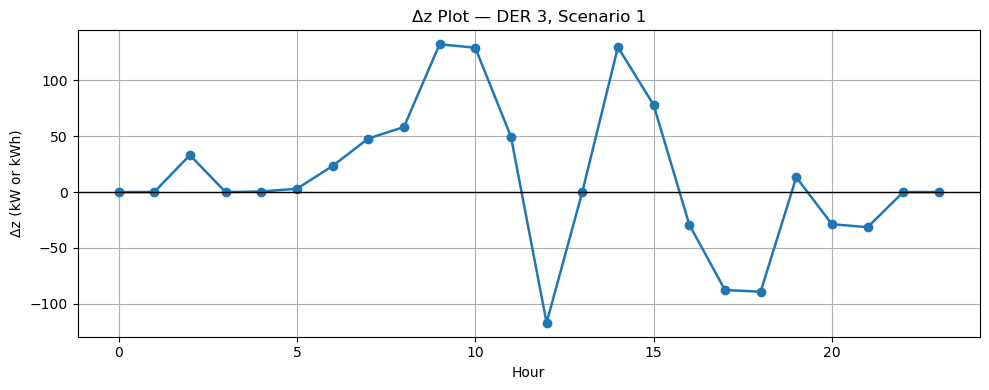

In [175]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dz_for_i(dz_array, i, s=0, title_prefix="Δz Plot"):
    """
    dz_array: shape (I, T, S)
    i: DER index
    s: scenario index to visualize (default=0)
    """
    dz_i = dz_array[i, :, s]   # shape (T,)

    T = dz_i.shape[0]
    hours = np.arange(T)

    plt.figure(figsize=(10, 4))
    plt.plot(hours, dz_i, marker='o', linewidth=1.8)
    plt.axhline(0, color='black', linewidth=1)

    plt.title(f"{title_prefix} — DER {i}, Scenario {s}")
    plt.xlabel("Hour")
    plt.ylabel("Δz (kW or kWh)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_dz_for_i(dz_ind, i=3, s=1)


### Holistic Optimization (Linear Decision Rule + MILP - M) (original)

In [307]:
m2 = gp.Model("holistic_MILP_M")
m2.setParam("MIPGap", 1e-5)
m2.setParam(GRB.Param.TimeLimit, 1200)

x_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x") ; yp_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp") ; ym_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")
dp_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dp") ; dm_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dm")
z_hol = m2.addVars(I, T + 1, S, vtype=GRB.CONTINUOUS, lb=0, name="z") ; zc_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zc") ; zd_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zd")

# phi1_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi1") ; phi2_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi2") 
# phi3_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi3") ; phi4_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi4")
# phi5_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi5") ; phi6_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi6") 

zc0_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc0") ; zc1_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc1") ; zc2_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc2")
zd0_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd0") ; zd1_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd1") ; zd2_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd2")

m2.update()

obj = (gp.quicksum(P_DA[t] * x_hol[i, t] for i in range(I) for t in range(T)) + 
       gp.quicksum((1/S) * (P_RT[t, s] * yp_hol[i, t, s] - P_PN[t, s] * ym_hol[i, t, s]) for i in range(I) for t in range(T) for s in range(S)))
m2.setObjective(obj, GRB.MAXIMIZE)

for i, t, s in product(range(I), range(T), range(S)):
    m2.addConstr(R[i, t, s] - x_hol[i, t] == yp_hol[i, t, s] - ym_hol[i, t, s] + dp_hol[i, t, s] - dm_hol[i, t, s] + zc_hol[i, t, s] - zd_hol[i, t, s])
    m2.addConstr(R[i, t, s] + zd_hol[i, t, s] >= yp_hol[i, t, s] + dp_hol[i, t, s] + zc_hol[i, t, s])
    m2.addConstr(zd_hol[i, t, s]/INEFF <= z_hol[i, t, s])
    m2.addConstr(zd_hol[i, t, s]/INEFF <= DRATE[i])
    m2.addConstr(zc_hol[i, t, s]*INEFF <= K[i] - z_hol[i, t, s])
    m2.addConstr(zc_hol[i, t, s]*INEFF <= CRATE[i])
    m2.addConstr(z_hol[i, t, s] <= K[i])
    m2.addConstr(z_hol[i, t + 1, s] == z_hol[i, t, s] + INEFF * zc_hol[i, t, s] - zd_hol[i, t, s] / INEFF)
for i, s in product(range(I), range(S)): m2.addConstr(z_hol[i, 0, s] == K0[i])

balance_constraints = {}
for t, s in product(range(T), range(S)):
    balance_constraints[t, s] = m2.addConstr(gp.quicksum(dp_hol[i, t, s] for i in range(I)) == gp.quicksum(dm_hol[i, t, s] for i in range(I)), name=f"balance_{t}_{s}")

for i, t, s in product(range(I), range(T), range(S)):
    m2.addConstr(zc_hol[i, t, s] == zc0_hol[i, t] + zc1_hol[i, t] * R[i, t, s] + zc2_hol[i, t] * (P_RT[t, s] - P_DA[t]))
    m2.addConstr(zd_hol[i, t, s] == zd0_hol[i, t] + zd1_hol[i, t] * R[i, t, s] + zd2_hol[i, t] * (P_RT[t, s] - P_DA[t]))

# for i, t, s in product(range(I), range(T), range(S)):
    # m2.addConstr(dp_hol[i, t, s] <= MDP[i,t,s] * phi1_hol[i, t, s]) ; m2.addConstr(dm_hol[i, t, s] <= MDM[i,t,s] * (1 - phi1_hol[i, t, s]))
#     m2.addConstr(zc_hol[i, t, s] <= MYP[i,t,s] * phi2_hol[i, t, s]) ; m2.addConstr(zd_hol[i, t, s] <= MYM[i,t,s] * (1 - phi2_hol[i, t, s]))
#     m2.addConstr(ym_hol[i, t, s] <= MYM[i,t,s] * phi3_hol[i, t, s]) ; m2.addConstr(zc_hol[i, t, s] <= MZC[i,t,s] * (1 - phi3_hol[i, t, s]))
#     m2.addConstr(ym_hol[i, t, s] <= MYM[i,t,s] * phi4_hol[i, t, s]) ; m2.addConstr(dp_hol[i, t, s] <= MDP[i,t,s] * (1 - phi4_hol[i, t, s]))
#     m2.addConstr(dm_hol[i, t, s] <= MDM[i,t,s] * phi5_hol[i, t, s]) ; m2.addConstr(zc_hol[i, t, s] <= MZC[i,t,s] * (1 - phi5_hol[i, t, s]))
#     m2.addConstr(yp_hol[i, t, s] <= MYP[i,t,s] * phi6_hol[i, t, s]) ; m2.addConstr(dm_hol[i, t, s] <= MDM[i,t,s] * (1 - phi6_hol[i, t, s])) 

m2.optimize()

if m2.status == GRB.OPTIMAL or m2.status == GRB.TIME_LIMIT:
    x_hol = np.array([[x_hol[i, t].X for t in range(T)] for i in range(I)])
    yp_hol = np.array([[[yp_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; ym_hol = np.array([[[ym_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    dp_hol = np.array([[[dp_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; dm_hol = np.array([[[dm_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    zc_hol = np.array([[[zc_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; zd_hol = np.array([[[zd_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    z_hol = np.array([[[z_hol[i, t, s].X for s in range(S)] for t in range(T+1)] for i in range(I)]) ; original_objval = m2.objVal
    OBJ_HOL = m2.objVal
    zc0_hol = np.array([[zc0_hol[i, t].X for t in range(T)] for i in range(I)]) ; zc1_hol = np.array([[zc1_hol[i, t].X for t in range(T)] for i in range(I)]) ; zc2_hol = np.array([[zc2_hol[i, t].X for t in range(T)] for i in range(I)])
    zd0_hol = np.array([[zd0_hol[i, t].X for t in range(T)] for i in range(I)]) ; zd1_hol = np.array([[zd1_hol[i, t].X for t in range(T)] for i in range(I)]) ; zd2_hol = np.array([[zd2_hol[i, t].X for t in range(T)] for i in range(I)])

    lambda_dual = {}
    for t, s in product(range(T), range(S)): 
        lambda_dual[t, s] = balance_constraints[t, s].Pi
    print("Direct dual extraction successful!")
else:
    print(f"⚠️ Model finished with status: {m2.status}")

Set parameter MIPGap to value 1e-05
Set parameter TimeLimit to value 1200
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
TimeLimit  1200
MIPGap  1e-05

Optimize a model with 486800 rows, 339680 columns and 1502800 nonzeros
Model fingerprint: 0x0e23e669
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [2e-02, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 276744 rows and 123197 columns
Presolve time: 0.42s
Presolved: 210056 rows, 216483 columns, 1027701 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 4.68s
Ordering time: 5.02s

Barrier statistics:
 Dense cols : 1154
 AA' NZ     : 1.405e+06
 Factor NZ  : 1.120e+07 (roughly 270 

In [308]:
header = (f"{'t':>2} | {'R':>8} {'x':>8} {'y+':>8} {'y-':>8} {'d+':>8} {'d-':>8} {'zc':>8} {'zd':>8} {'z':>8}\n" + "-" * 90)
print("\n[HOLISTIC]") ; print(header)
for t in range(7, 22):
    R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_hol[:, t].sum()
    yp_avg = np.mean([yp_hol[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_hol[:, t, s].sum() for s in range(S)])
    dp_avg = np.mean([dp_hol[:, t, s].sum() for s in range(S)]) ; dm_avg = np.mean([dm_hol[:, t, s].sum() for s in range(S)])
    zc_avg = np.mean([zc_hol[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_hol[:, t, s].sum() for s in range(S)]) ; z_avg = np.mean([z_hol[:, t, s].sum() for s in range(S)])
    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {dp_avg:>8.2f} {dm_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")


[HOLISTIC]
 t |        R        x       y+       y-       d+       d-       zc       zd        z
------------------------------------------------------------------------------------------
 7 |   584.90   339.40   129.37     5.39   285.57   285.57   121.51     0.00    10.71
 8 |  1411.88  1012.51   171.68    58.58   860.26   860.26   286.27     0.00   120.07
 9 |  1592.72  1318.92   148.61    68.93  1186.93  1186.93   194.12     0.00   377.72
10 |  1664.52  1438.00   152.94    75.21  1306.37  1306.37   148.79     0.00   552.42
11 |  1933.90  1696.35   192.01    69.39  1550.52  1550.52   114.94     0.00   686.34
12 |  3154.31  2859.70   386.93   107.02  2693.28  2693.28    14.70     0.00   789.78
13 |  3753.30     0.00  4450.80     0.00     0.00     0.00     0.00   697.50   803.01
14 |  4102.70  2468.83  1633.87     0.00  2224.56  2224.56     0.00     0.00    28.01
15 |  6829.26  6817.20   532.93   520.87  6013.70  6013.70     0.00    -0.00    28.01
16 |  6609.49  6423.02   549.88   363

In [309]:
for i, t, s in product(range(I), range(T), range(S)):
    if dp_hol[i, t, s] * dm_hol[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, dp={dp_hol[i, t, s]}, dm={dm_hol[i, t, s]}")
    # if zc_hol[i, t, s] * zd_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_hol[i, t, s]}, zd={zd_hol[i, t, s]}")
    # if dp_hol[i, t, s] * ym_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, dp={dp_hol[i, t, s]}, ym={ym_hol[i, t, s]}, P_RT={P_RT[t, s]}, P_IN={-lambda_dual[t, s] * S}, P_PN={P_PN[t, s]}")
    # if zc_hol[i, t, s] * ym_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_hol[i, t, s]}, ym={ym_hol[i, t, s]}")
    # if zc_hol[i, t, s] * dm_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_hol[i, t, s]}, dm={dm_hol[i, t, s]}")
    # if dm_hol[i, t, s] * yp_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, dm={dm_hol[i, t, s]}, yp={yp_hol[i, t, s]}, P_RT={P_RT[t, s]}, P_IN={-lambda_dual[t, s] * S}, P_PN={P_PN[t, s]}")

i=0, t=6, s=17, dp=10.477631680113907, dm=3.9846227999800163
i=0, t=6, s=36, dp=24.815167557628122, dm=3.9846227999800163
i=0, t=6, s=62, dp=19.661739761692466, dm=3.984622799980011
i=0, t=6, s=80, dp=23.845336265814534, dm=3.984622799980013
i=0, t=6, s=82, dp=22.850427432011422, dm=3.9846227999800163
i=0, t=6, s=105, dp=12.628405198562314, dm=3.9846227999800163
i=0, t=6, s=106, dp=25.47587220248097, dm=3.9846227999800163
i=0, t=6, s=145, dp=11.274402993519399, dm=3.9846227999800163
i=0, t=6, s=151, dp=24.146309271171777, dm=3.9846227999800163
i=0, t=6, s=186, dp=20.6419076760479, dm=3.9846227999800163
i=0, t=6, s=192, dp=17.339036610665993, dm=3.9846227999800163
i=0, t=6, s=199, dp=10.830330889241065, dm=3.9846227999800163
i=0, t=7, s=0, dp=99.79734365481305, dm=29.074513725650505
i=0, t=7, s=1, dp=71.4921155865541, dm=29.074513725650505
i=0, t=7, s=2, dp=137.26690367173705, dm=29.074513725650476
i=0, t=7, s=3, dp=87.64224279196925, dm=29.074513725650505
i=0, t=7, s=4, dp=116.78244393

### Holistic Optimization (Linear Decision Rule + MILP - M) (1) - 이것저것 실험해보는 버젼

In [386]:
m2 = gp.Model("holistic_MILP_M")
m2.setParam("MIPGap", 1e-5)
m2.setParam(GRB.Param.TimeLimit, 1500)

x_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x") ; yp_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp") ; ym_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")
dp_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dp") ; dm_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dm")
z_hol = m2.addVars(I, T + 1, S, vtype=GRB.CONTINUOUS, lb=0, name="z") ; zc_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zc") ; zd_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zd")

# phi1_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi1") ; phi2_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi2") 
# phi3_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi3") ; phi4_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi4")
# phi5_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi5") ; phi6_hol = m2.addVars(I, T, S, vtype=GRB.BINARY, name="phi6") 

zc0_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc0") ; zc1_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc1") ; zc2_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc2")
zd0_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd0") ; zd1_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd1") ; zd2_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd2")

m2.update()

obj = (gp.quicksum(P_DA[t] * x_hol[i, t] for i in range(I) for t in range(T)) + 
       gp.quicksum((1/S) * (P_RT[t, s] * yp_hol[i, t, s] - P_PN[t, s] * ym_hol[i, t, s]) for i in range(I) for t in range(T) for s in range(S)))
m2.setObjective(obj, GRB.MAXIMIZE)

for i, t, s in product(range(I), range(T), range(S)):
    m2.addConstr(R[i, t, s] - x_hol[i, t] == yp_hol[i, t, s] - ym_hol[i, t, s] + dp_hol[i, t, s] - dm_hol[i, t, s] + zc_hol[i, t, s] - zd_hol[i, t, s])
    # m2.addConstr(R[i, t, s] + zd_hol[i, t, s] + dm_hol[i, t, s] + ym_hol[i, t, s] >= yp_hol[i, t, s] + dp_hol[i, t, s] + zc_hol[i, t, s])
    # m2.addConstr(R[i, t, s] + zd_hol[i, t, s] >= yp_hol[i, t, s] + dp_hol[i, t, s] + zc_hol[i, t, s])
    # m2.addConstr(0 >= -ym_hol[i, t, s] -dm_hol[i, t, s] + zc_hol[i, t, s] - zd_hol[i, t, s])
    m2.addConstr(zd_hol[i, t, s]/INEFF <= z_hol[i, t, s])
    m2.addConstr(zd_hol[i, t, s]/INEFF <= DRATE[i])
    m2.addConstr(zc_hol[i, t, s]*INEFF <= K[i] - z_hol[i, t, s])
    m2.addConstr(zc_hol[i, t, s]*INEFF <= CRATE[i])
    m2.addConstr(z_hol[i, t, s] <= K[i])
    m2.addConstr(z_hol[i, t + 1, s] == z_hol[i, t, s] + INEFF * zc_hol[i, t, s] - zd_hol[i, t, s] / INEFF)
for i, s in product(range(I), range(S)): m2.addConstr(z_hol[i, 0, s] == K0[i])

balance_constraints = {}
for t, s in product(range(T), range(S)):
    balance_constraints[t, s] = m2.addConstr(gp.quicksum(dp_hol[i, t, s] for i in range(I)) == gp.quicksum(dm_hol[i, t, s] for i in range(I)), name=f"balance_{t}_{s}")

for i, t, s in product(range(I), range(T), range(S)):
    m2.addConstr(zc_hol[i, t, s] == zc0_hol[i, t] + zc1_hol[i, t] * R[i, t, s] + zc2_hol[i, t] * (P_RT[t, s] - P_DA[t]))
    m2.addConstr(zd_hol[i, t, s] == zd0_hol[i, t] + zd1_hol[i, t] * R[i, t, s] + zd2_hol[i, t] * (P_RT[t, s] - P_DA[t]))

# for i, t, s in product(range(I), range(T), range(S)):
    # m2.addConstr(dp_hol[i, t, s] <= MDP[i,t,s] * phi1_hol[i, t, s]) ; m2.addConstr(dm_hol[i, t, s] <= MDM[i,t,s] * (1 - phi1_hol[i, t, s]))
#     m2.addConstr(zc_hol[i, t, s] <= MYP[i,t,s] * phi2_hol[i, t, s]) ; m2.addConstr(zd_hol[i, t, s] <= MYM[i,t,s] * (1 - phi2_hol[i, t, s]))
#     m2.addConstr(ym_hol[i, t, s] <= MYM[i,t,s] * phi3_hol[i, t, s]) ; m2.addConstr(zc_hol[i, t, s] <= MZC[i,t,s] * (1 - phi3_hol[i, t, s]))
    # m2.addConstr(ym_hol[i, t, s] <= MYM[i,t,s] * phi4_hol[i, t, s]) ; m2.addConstr(dp_hol[i, t, s] <= MDP[i,t,s] * (1 - phi4_hol[i, t, s]))
#     m2.addConstr(dm_hol[i, t, s] <= MDM[i,t,s] * phi5_hol[i, t, s]) ; m2.addConstr(zc_hol[i, t, s] <= MZC[i,t,s] * (1 - phi5_hol[i, t, s]))
    # m2.addConstr(yp_hol[i, t, s] <= MYP[i,t,s] * phi6_hol[i, t, s]) ; m2.addConstr(dm_hol[i, t, s] <= MDM[i,t,s] * (1 - phi6_hol[i, t, s])) 

m2.optimize()

if m2.status == GRB.OPTIMAL or m2.status == GRB.TIME_LIMIT:
    x_hol = np.array([[x_hol[i, t].X for t in range(T)] for i in range(I)])
    yp_hol = np.array([[[yp_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; ym_hol = np.array([[[ym_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    dp_hol = np.array([[[dp_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; dm_hol = np.array([[[dm_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    zc_hol = np.array([[[zc_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; zd_hol = np.array([[[zd_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    z_hol = np.array([[[z_hol[i, t, s].X for s in range(S)] for t in range(T+1)] for i in range(I)]) ; original_objval = m2.objVal
    OBJ_HOL = m2.objVal
    zc0_hol = np.array([[zc0_hol[i, t].X for t in range(T)] for i in range(I)]) ; zc1_hol = np.array([[zc1_hol[i, t].X for t in range(T)] for i in range(I)]) ; zc2_hol = np.array([[zc2_hol[i, t].X for t in range(T)] for i in range(I)])
    zd0_hol = np.array([[zd0_hol[i, t].X for t in range(T)] for i in range(I)]) ; zd1_hol = np.array([[zd1_hol[i, t].X for t in range(T)] for i in range(I)]) ; zd2_hol = np.array([[zd2_hol[i, t].X for t in range(T)] for i in range(I)])

    lambda_dual = {}
    for t, s in product(range(T), range(S)): 
        lambda_dual[t, s] = balance_constraints[t, s].Pi
    print("Direct dual extraction successful!")
else:
    print(f"⚠️ Model finished with status: {m2.status}")

Set parameter MIPGap to value 1e-05
Set parameter TimeLimit to value 1500
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
TimeLimit  1500
MIPGap  1e-05

Optimize a model with 438800 rows, 339680 columns and 1310800 nonzeros
Model fingerprint: 0x882ee716
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [2e-02, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 242400 rows and 227614 columns
Presolve time: 2.91s
Presolved: 51845 rows, 329218 columns, 1740808 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.88s

Barrier statistics:
 Free vars  : 50371
 AA' NZ     : 2.080e+06
 Factor NZ  : 2.440e+07 (roughly 350 MB of memory)
 Factor

In [354]:
header = (f"{'t':>2} | {'R':>8} {'x':>8} {'y+':>8} {'y-':>8} {'d+':>8} {'d-':>8} {'zc':>8} {'zd':>8} {'z':>8}\n" + "-" * 90)
print("\n[HOLISTIC]") ; print(header)
for t in range(7, 22):
    R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_hol[:, t].sum()
    yp_avg = np.mean([yp_hol[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_hol[:, t, s].sum() for s in range(S)])
    dp_avg = np.mean([dp_hol[:, t, s].sum() for s in range(S)]) ; dm_avg = np.mean([dm_hol[:, t, s].sum() for s in range(S)])
    zc_avg = np.mean([zc_hol[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_hol[:, t, s].sum() for s in range(S)]) ; z_avg = np.mean([z_hol[:, t, s].sum() for s in range(S)])
    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {dp_avg:>8.2f} {dm_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")


[HOLISTIC]
 t |        R        x       y+       y-       d+       d-       zc       zd        z
------------------------------------------------------------------------------------------
 7 |   584.90   339.40   129.37     5.39   285.57   285.57   121.51     0.00    10.71
 8 |  1411.88  1012.51   171.68    58.58   860.26   860.26   286.27     0.00   120.07
 9 |  1592.72  1318.92   148.61    68.93  1186.93  1186.93   194.12     0.00   377.72
10 |  1664.52  1438.00   152.94    75.21  1306.37  1306.37   148.79     0.00   552.42
11 |  1933.90  1696.35   192.01    69.39  1550.52  1550.52   114.94     0.00   686.34
12 |  3154.31  2859.70   386.93   107.02  2693.28  2693.28    14.70     0.00   789.78
13 |  3753.30     0.00  4450.80     0.00     0.00     0.00     0.00   697.50   803.01
14 |  4102.70  2468.83  1633.87     0.00  2224.56  2224.56     0.00     0.00    28.01
15 |  6829.26  6817.20   532.93   520.87  6013.70  6013.70     0.00    -0.00    28.01
16 |  6609.49  6423.02   549.88   363

In [355]:
for i, t, s in product(range(I), range(T), range(S)):
    if dp_hol[i, t, s] * dm_hol[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, dp={dp_hol[i, t, s]}, dm={dm_hol[i, t, s]}")
    if zc_hol[i, t, s] * zd_hol[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, zc={zc_hol[i, t, s]}, zd={zd_hol[i, t, s]}")
    if dp_hol[i, t, s] * ym_hol[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, dp={dp_hol[i, t, s]}, ym={ym_hol[i, t, s]}, P_RT={P_RT[t, s]}, P_IN={-lambda_dual[t, s] * S}, P_PN={P_PN[t, s]}")
    # if zc_hol[i, t, s] * ym_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_hol[i, t, s]}, ym={ym_hol[i, t, s]}")
    # if zc_hol[i, t, s] * dm_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_hol[i, t, s]}, dm={dm_hol[i, t, s]}")
    if dm_hol[i, t, s] * yp_hol[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s},  dm={dm_hol[i, t, s]}, yp={yp_hol[i, t, s]}, P_RT={P_RT[t, s]}, P_IN={-lambda_dual[t, s] * S}, P_PN={P_PN[t, s]}")

i=0, t=6, s=14, dp=5.494920450277064, ym=3.9846227999800163, P_RT=50.31527066106418, P_IN=161.642, P_PN=161.642
i=0, t=6, s=17, dp=10.477631680113907, dm=3.9846227999800163
i=0, t=6, s=17,  dm=3.9846227999800163, yp=33.88114418760342, P_RT=84.14894604194136, P_IN=84.14894604194136, P_PN=168.29789208388272
i=0, t=6, s=36, dp=24.815167557628122, dm=3.9846227999800163
i=0, t=6, s=36,  dm=3.9846227999800163, yp=14.9976108737577, P_RT=80.19134070682786, P_IN=80.19134070682786, P_PN=161.642
i=0, t=6, s=40,  dm=3.9846227999800163, yp=10.162134207414104, P_RT=54.37840319117535, P_IN=54.37840319117535, P_PN=161.642
i=0, t=6, s=62, dp=19.661739761692466, dm=3.984622799980011
i=0, t=6, s=62,  dm=3.984622799980011, yp=13.64130504623987, P_RT=74.52416713729393, P_IN=74.52416713729393, P_PN=161.642
i=0, t=6, s=76, dp=5.642515126919307, ym=3.9846227999800163, P_RT=50.44376204010575, P_IN=161.642, P_PN=161.642
i=0, t=6, s=77, dp=10.908902042339282, ym=3.9846227999800163, P_RT=55.028516265144866, P_IN=

In [356]:
for i, t, s in product(range(I), range(T), range(S)):
    if dp_hol[i, t, s] * ym_hol[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, dp={dp_hol[i, t, s]}, dm={dm_hol[i, t, s]}, yp={yp_hol[i, t, s]}, ym={ym_hol[i, t, s]}, P_RT={P_RT[t, s]}, P_IN={-lambda_dual[t, s] * S}, P_PN={P_PN[t, s]}")
    if dm_hol[i, t, s] * yp_hol[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, dp={dp_hol[i, t, s]}, dm={dm_hol[i, t, s]}, yp={yp_hol[i, t, s]}, ym={ym_hol[i, t, s]}, P_RT={P_RT[t, s]}, P_IN={-lambda_dual[t, s] * S}, P_PN={P_PN[t, s]}")

i=0, t=6, s=14, dp=5.494920450277064, dm=0.0, yp=0.0, ym=3.9846227999800163, P_RT=50.31527066106418, P_IN=161.642, P_PN=161.642
i=0, t=6, s=17, dp=10.477631680113907, dm=3.9846227999800163, yp=33.88114418760342, ym=0.0, P_RT=84.14894604194136, P_IN=84.14894604194136, P_PN=168.29789208388272
i=0, t=6, s=36, dp=24.815167557628122, dm=3.9846227999800163, yp=14.9976108737577, ym=0.0, P_RT=80.19134070682786, P_IN=80.19134070682786, P_PN=161.642
i=0, t=6, s=40, dp=0.0, dm=3.9846227999800163, yp=10.162134207414104, ym=0.0, P_RT=54.37840319117535, P_IN=54.37840319117535, P_PN=161.642
i=0, t=6, s=62, dp=19.661739761692466, dm=3.984622799980011, yp=13.64130504623987, ym=0.0, P_RT=74.52416713729393, P_IN=74.52416713729393, P_PN=161.642
i=0, t=6, s=76, dp=5.642515126919307, dm=0.0, yp=0.0, ym=3.9846227999800163, P_RT=50.44376204010575, P_IN=161.642, P_PN=161.642
i=0, t=6, s=77, dp=10.908902042339282, dm=0.0, yp=0.0, ym=3.9846227999800163, P_RT=55.028516265144866, P_IN=161.64199999999875, P_PN=161.

### Holistic Optimization (Linear Decision Rule + MILP - M) (2) - zc/zd 없앤버젼

In [366]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from itertools import product

m2 = gp.Model("holistic_MILP_dz")
m2.setParam("MIPGap", 1e-5)
m2.setParam(GRB.Param.TimeLimit, 1500)

# ---------------------------------------------------------
# Variables
# ---------------------------------------------------------
x_hol  = m2.addVars(I, T,    vtype=GRB.CONTINUOUS, lb=0, name="x")
yp_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp")
ym_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")

dp_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dp")  # 자유변수
dm_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dm")  # 자유변수

z_hol  = m2.addVars(I, T+1, S, vtype=GRB.CONTINUOUS, lb=0, name="z")

# net storage power (charging +, discharging -)
dz_hol = m2.addVars(I, T, S,
                    vtype=GRB.CONTINUOUS,
                    lb=-GRB.INFINITY, name="dz")

# LDR coefficients ONLY for dz
dz0_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz0")
dz1_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz1")
dz2_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz2")

m2.update()

# ---------------------------------------------------------
# Objective
# ---------------------------------------------------------
obj = (
    gp.quicksum(P_DA[t] * x_hol[i, t] for i in range(I) for t in range(T))
    +
    gp.quicksum(
        (1 / S) * (P_RT[t, s] * yp_hol[i, t, s] - P_PN[t, s] * ym_hol[i, t, s])
        for i in range(I) for t in range(T) for s in range(S)
    )
)
m2.setObjective(obj, GRB.MAXIMIZE)

# ---------------------------------------------------------
# Constraints
# ---------------------------------------------------------
for i, t, s in product(range(I), range(T), range(S)):

    # (1) LDR: dz as affine function of (R, price spread)
    m2.addConstr(
        dz_hol[i, t, s] ==
        dz0_hol[i, t]
        + dz1_hol[i, t] * R[i, t, s]
        + dz2_hol[i, t] * (P_RT[t, s] - P_DA[t])
    )

    # (2) Power balance (with dz)
    m2.addConstr(
        R[i, t, s] - x_hol[i, t]
        ==
        yp_hol[i, t, s] - ym_hol[i, t, s]
        + dp_hol[i, t, s] - dm_hol[i, t, s]
        + dz_hol[i, t, s]
    )

    # (3) SOC transition (lossless storage)
    m2.addConstr(
        z_hol[i, t+1, s] == z_hol[i, t, s] + dz_hol[i, t, s]
    )

    # (4) SOC upper bound
    m2.addConstr(z_hol[i, t, s] <= K[i])

    # (5) Discharge limits (dz < 0 구간에서만 active)
    m2.addConstr(-dz_hol[i, t, s] <= z_hol[i, t, s])   # cannot discharge beyond SOC
    m2.addConstr(-dz_hol[i, t, s] <= DRATE[i])         # discharge rate limit

    # (6) Charge limits (dz > 0 구간에서만 active)
    m2.addConstr(dz_hol[i, t, s] <= K[i] - z_hol[i, t, s])  # capacity limit
    m2.addConstr(dz_hol[i, t, s] <= CRATE[i])               # charge rate limit

# Initial SOC
for i, s in product(range(I), range(S)):
    m2.addConstr(z_hol[i, 0, s] == K0[i])

# ---------------------------------------------------------
# Internal market clearing (dp = dm)
# ---------------------------------------------------------
balance_constraints = {}
for t, s in product(range(T), range(S)):
    balance_constraints[t, s] = m2.addConstr(
        gp.quicksum(dp_hol[i, t, s] for i in range(I))
        ==
        gp.quicksum(dm_hol[i, t, s] for i in range(I)),
        name=f"balance_{t}_{s}"
    )

# ---------------------------------------------------------
# Solve
# ---------------------------------------------------------
m2.optimize()

# ---------------------------------------------------------
# Extract solution (이름 동일하게)
# ---------------------------------------------------------
if m2.status in [GRB.OPTIMAL, GRB.TIME_LIMIT]:

    x_hol  = np.array([[x_hol[i, t].X for t in range(T)] for i in range(I)])
    z_hol  = np.array([[[z_hol[i, t, s].X for s in range(S)] for t in range(T+1)] for i in range(I)])

    yp_hol = np.array([[[yp_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    ym_hol = np.array([[[ym_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])

    dp_hol = np.array([[[dp_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    dm_hol = np.array([[[dm_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])

    dz_hol = np.array([[[dz_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])

    dz0_hol = np.array([[dz0_hol[i, t].X for t in range(T)] for i in range(I)])
    dz1_hol = np.array([[dz1_hol[i, t].X for t in range(T)] for i in range(I)])
    dz2_hol = np.array([[dz2_hol[i, t].X for t in range(T)] for i in range(I)])

    zc_hol = np.maximum(dz_hol, 0.0)  
    zd_hol = np.maximum(-dz_hol, 0.0)  

    # dual prices for internal market balance
    lambda_dual = {(t, s): balance_constraints[t, s].Pi
                   for t, s in product(range(T), range(S))}

else:
    print(f"Model ended with status {m2.status}")


Set parameter MIPGap to value 1e-05
Set parameter TimeLimit to value 1500
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
TimeLimit  1500
MIPGap  1e-05

Optimize a model with 390800 rows, 290960 columns and 1040400 nonzeros
Model fingerprint: 0x6f38d223
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [2e-02, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 248400 rows and 189506 columns
Presolve time: 0.89s
Presolved: 33361 rows, 188214 columns, 644379 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.17s

Barrier statistics:
 Free vars  : 32706
 AA' NZ     : 8.024e+05
 Factor NZ  : 5.998e+06 (roughly 140 MB of memory)
 Factor 

In [369]:
for i, t, s in product(range(I), range(T), range(S)):
    if dp_hol[i, t, s] * dm_hol[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, dp={dp_hol[i, t, s]}, dm={dm_hol[i, t, s]}")
    # if zc_hol[i, t, s] * zd_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_hol[i, t, s]}, zd={zd_hol[i, t, s]}")
    if dp_hol[i, t, s] * ym_hol[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, dp={dp_hol[i, t, s]}, ym={ym_hol[i, t, s]}, P_RT={P_RT[t, s]}, P_IN={-lambda_dual[t, s] * S}, P_PN={P_PN[t, s]}")
    # if zc_hol[i, t, s] * ym_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_hol[i, t, s]}, ym={ym_hol[i, t, s]}")
    # if zc_hol[i, t, s] * dm_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_hol[i, t, s]}, dm={dm_hol[i, t, s]}")
    # if dm_hol[i, t, s] * yp_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s},  dm={dm_hol[i, t, s]}, yp={yp_hol[i, t, s]}, P_RT={P_RT[t, s]}, P_IN={-lambda_dual[t, s] * S}, P_PN={P_PN[t, s]}")

i=1, t=3, s=31, dp=3.376095846968364, ym=3.376095846968364, P_RT=57.67618188563306, P_IN=143.286, P_PN=143.286
i=2, t=10, s=112, dp=186.89326180527755, ym=117.13074588658387, P_RT=45.02208886131929, P_IN=229.502, P_PN=229.502
i=2, t=11, s=62, dp=459.20391214229994, ym=238.03242850434924, P_RT=55.21483928618897, P_IN=239.95400000000004, P_PN=239.95400000000004
i=2, t=19, s=63, dp=318.7228080563798, ym=0.6454903768406552, P_RT=82.04848508959343, P_IN=245.15400000000005, P_PN=245.15400000000002
i=2, t=19, s=130, dp=502.29184656700386, ym=68.5067246481423, P_RT=73.24711326561781, P_IN=245.15400000000005, P_PN=245.15400000000002
i=3, t=2, s=63, dp=2.1418175567391167, ym=2.1418175567391167, P_RT=38.76338784292234, P_IN=149.11, P_PN=149.11
i=3, t=2, s=77, dp=7.279315587996857, ym=7.279315587996857, P_RT=55.74064578615851, P_IN=149.11, P_PN=149.11
i=3, t=2, s=85, dp=5.125772520720792, ym=5.125772520720792, P_RT=48.62409685074938, P_IN=149.11, P_PN=149.11
i=3, t=2, s=93, dp=2.0032693337570384, 

### Holistic Optimization (Linear Decision Rule + MILP - M) (3) - dp/dm/zc/zd 없앤버젼

In [387]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from itertools import product

m2 = gp.Model("holistic_MILP_dz_D")
m2.setParam("MIPGap", 1e-5)
m2.setParam(GRB.Param.TimeLimit, 1500)

# ---------------------------------------------------------
# Variables
# ---------------------------------------------------------
x_hol  = m2.addVars(I, T,    vtype=GRB.CONTINUOUS, lb=0, name="x")
yp_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp")
ym_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")

# *** NEW: internal market net variable D ***
D_hol = m2.addVars(I, T, S, vtype=GRB.CONTINUOUS,
                   lb=-GRB.INFINITY, name="D")

# SOC
z_hol  = m2.addVars(I, T+1, S, vtype=GRB.CONTINUOUS, lb=0, name="z")

# net storage power (charging +, discharging -)
dz_hol = m2.addVars(I, T, S,
                    vtype=GRB.CONTINUOUS,
                    lb=-GRB.INFINITY, name="dz")

# LDR coefficients ONLY for dz
dz0_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz0")
dz1_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz1")
dz2_hol = m2.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz2")

m2.update()

# ---------------------------------------------------------
# Objective
# ---------------------------------------------------------
obj = (
    gp.quicksum(P_DA[t] * x_hol[i, t] for i in range(I) for t in range(T))
    +
    gp.quicksum(
        (1 / S) * (P_RT[t, s] * yp_hol[i, t, s] - P_PN[t, s] * ym_hol[i, t, s])
        for i in range(I) for t in range(T) for s in range(S)
    )
)
m2.setObjective(obj, GRB.MAXIMIZE)

# ---------------------------------------------------------
# Constraints
# ---------------------------------------------------------
for i, t, s in product(range(I), range(T), range(S)):

    # (1) LDR: dz as affine function of (R, price spread)
    m2.addConstr(
        dz_hol[i, t, s] ==
        dz0_hol[i, t]
        + dz1_hol[i, t] * R[i, t, s]
        + dz2_hol[i, t] * (P_RT[t, s] - P_DA[t])
    )

    # (2) Power balance (replace dp-dm → D)
    m2.addConstr(
        R[i, t, s] - x_hol[i, t]
        ==
        yp_hol[i, t, s] - ym_hol[i, t, s]
        + D_hol[i, t, s]         # <--- NOTE
        + dz_hol[i, t, s]
    )

    # (3) SOC transition (lossless storage)
    m2.addConstr(
        z_hol[i, t+1, s] == z_hol[i, t, s] + dz_hol[i, t, s]
    )

    # (4) SOC upper bound
    m2.addConstr(z_hol[i, t, s] <= K[i])

    # (5) Discharge limits (dz < 0)
    m2.addConstr(-dz_hol[i, t, s] <= z_hol[i, t, s])
    m2.addConstr(-dz_hol[i, t, s] <= DRATE[i])

    # (6) Charge limits (dz > 0)
    m2.addConstr(dz_hol[i, t, s] <= K[i] - z_hol[i, t, s])
    m2.addConstr(dz_hol[i, t, s] <= CRATE[i])


# Initial SOC
for i, s in product(range(I), range(S)):
    m2.addConstr(z_hol[i, 0, s] == K0[i])

# ---------------------------------------------------------
# Internal Market Balancing
# sum_i D = 0
# ---------------------------------------------------------
balance_constraints = {}
for t, s in product(range(T), range(S)):
    balance_constraints[t, s] = m2.addConstr(
        gp.quicksum(D_hol[i, t, s] for i in range(I)) == 0,
        name=f"balance_{t}_{s}"
    )

# ---------------------------------------------------------
# Solve
# ---------------------------------------------------------
m2.optimize()

# ---------------------------------------------------------
# Extract solution (same variable names)
# ---------------------------------------------------------
if m2.status in [GRB.OPTIMAL, GRB.TIME_LIMIT]:

    x_hol  = np.array([[x_hol[i, t].X for t in range(T)] for i in range(I)])
    z_hol  = np.array([[[z_hol[i, t, s].X for s in range(S)] for t in range(T+1)] for i in range(I)])

    yp_hol = np.array([[[yp_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
    ym_hol = np.array([[[ym_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])

    D_hol  = np.array([[[D_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])

    dz_hol = np.array([[[dz_hol[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])

    dz0_hol = np.array([[dz0_hol[i, t].X for t in range(T)] for i in range(I)])
    dz1_hol = np.array([[dz1_hol[i, t].X for t in range(T)] for i in range(I)])
    dz2_hol = np.array([[dz2_hol[i, t].X for t in range(T)] for i in range(I)])

    # -----------------------------------------
    # Post-processing: Recover dp, dm (optional)
    # -----------------------------------------
    dp_hol = np.maximum(D_hol, 0.0)
    dm_hol = np.maximum(-D_hol, 0.0)

    zc_hol = np.maximum(dz_hol, 0.0)  
    zd_hol = np.maximum(-dz_hol, 0.0)  

    # dual prices
    lambda_dual = {(t, s): balance_constraints[t, s].Pi
                   for t, s in product(range(T), range(S))}

else:
    print(f"Model ended with status {m2.status}")


Set parameter MIPGap to value 1e-05
Set parameter TimeLimit to value 1500
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
TimeLimit  1500
MIPGap  1e-05

Optimize a model with 390800 rows, 242960 columns and 944400 nonzeros
Model fingerprint: 0xe4aed2eb
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [2e-02, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 248400 rows and 141506 columns
Presolve time: 0.76s
Presolved: 33361 rows, 188214 columns, 644379 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.17s

Barrier statistics:
 Free vars  : 32706
 AA' NZ     : 8.024e+05
 Factor NZ  : 5.998e+06 (roughly 140 MB of memory)
 Factor O

In [390]:
for i, t, s in product(range(I), range(T), range(S)):
    if dp_hol[i, t, s] * dm_hol[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, dp={dp_hol[i, t, s]}, dm={dm_hol[i, t, s]}")
    if zc_hol[i, t, s] * zd_hol[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, zc={zc_hol[i, t, s]}, zd={zd_hol[i, t, s]}")
    if dp_hol[i, t, s] * ym_hol[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, dp={dp_hol[i, t, s]}, ym={ym_hol[i, t, s]}, P_RT={P_RT[t, s]}, P_IN={-lambda_dual[t, s] * S}, P_PN={P_PN[t, s]}")
    # if zc_hol[i, t, s] * ym_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_hol[i, t, s]}, ym={ym_hol[i, t, s]}")
    # if zc_hol[i, t, s] * dm_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_hol[i, t, s]}, dm={dm_hol[i, t, s]}")
    # if dm_hol[i, t, s] * yp_hol[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s},  dm={dm_hol[i, t, s]}, yp={yp_hol[i, t, s]}, P_RT={P_RT[t, s]}, P_IN={-lambda_dual[t, s] * S}, P_PN={P_PN[t, s]}")

i=9, t=2, s=0, dp=4.533979408619622, ym=7.84014496441215, P_RT=57.59394965657514, P_IN=149.11, P_PN=149.11
i=9, t=2, s=1, dp=3.796943370306178, ym=6.565664234881732, P_RT=53.382329923140176, P_IN=149.11, P_PN=149.11
i=9, t=2, s=2, dp=0.1389235590953799, ym=0.24022624368544765, P_RT=32.47943288509933, P_IN=149.11, P_PN=149.11
i=9, t=2, s=3, dp=3.3486083631772763, ym=5.790404549796065, P_RT=50.820424581937885, P_IN=149.11, P_PN=149.11
i=9, t=2, s=4, dp=2.1900752298805735, ym=3.787072180475463, P_RT=44.20025846740715, P_IN=149.11, P_PN=149.11
i=9, t=2, s=5, dp=4.477635677295388, ym=7.7427155361756475, P_RT=57.27198660678519, P_IN=149.11, P_PN=149.11
i=9, t=2, s=6, dp=1.0354152662635365, ym=1.7904372857182902, P_RT=37.602224673422306, P_IN=149.11, P_PN=149.11
i=9, t=2, s=7, dp=1.2517724802798684, ym=2.164561596640297, P_RT=38.83854727456312, P_IN=149.11, P_PN=149.11
i=9, t=2, s=8, dp=0.3719278957865024, ym=0.6431367142363638, P_RT=33.81088156789348, P_IN=149.11, P_PN=149.11
i=9, t=2, s=9, 

### Individual Replay

In [370]:
lambda_rep = np.zeros((T, S))
data = []
# eps = 0.00001
eps = 0

for t in range(T):
    for s in range(S):
        lambda_rep[t, s] = lambda_dual[t, s]
        # lambda_rep[t,s] = np.clip(lambda_dual[t,s], -P_PN[t,s] / S, -P_RT[t,s] / S)
        # lambda_rep[t, s] = ((-P_RT[t, s] / S) + (-P_PN[t, s] / S))/2
        
        if abs(lambda_rep[t, s] - (-P_RT[t, s] / S)) < 0.001:
            lambda_rep[t, s] -= eps / S
            
        elif abs(lambda_rep[t, s] - (-P_PN[t, s] / S)) < 0.001:
            lambda_rep[t, s] += eps / S
    
    s_fixed = 29
    data.append({
        'Time': t, 
        'P_DA': round(P_DA[t], 2), 
        'P_RT_avg': round(P_RT[t, s_fixed], 5), 
        'Lambda': round(-lambda_rep[t, s_fixed] * S, 5), 
        'P_PN_avg': round(P_PN[t, s_fixed], 4)
    })

pd.DataFrame(data)

,Time,P_DA,P_RT_avg,Lambda,P_PN_avg
0,0,91.140,70.356,182.286,182.286
1,1,80.280,58.629,160.550,160.550
2,2,74.560,51.838,149.110,149.110
3,3,71.640,53.590,143.286,143.286
4,4,71.310,51.775,142.610,142.610
5,5,74.540,70.707,149.084,149.084
6,6,80.820,77.527,77.527,161.642
7,7,87.240,74.818,74.818,174.486
8,8,101.970,49.091,203.944,203.944
9,9,110.370,53.024,53.024,220.740


In [338]:
data_for_csv = []

for t in range(T):
    for s in range(S):
        row = {
            't': t,
            's': s,
            'P_DA': P_DA[t],
            'P_RT': P_RT[t, s],
            'P_PN': P_PN[t, s],
            'P_IN': -lambda_dual[t, s] * S
        }
        data_for_csv.append(row)

df = pd.DataFrame(data_for_csv)

output_filename = f'optimization_results_{SEED}.csv'
df.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"✅ 데이터가 '{output_filename}' 파일로 성공적으로 저장되었습니다.")

✅ 데이터가 'optimization_results_1.csv' 파일로 성공적으로 저장되었습니다.


In [ ]:
# m5 = gp.Model("DER_Individual_Replay")
# m5.setParam("MIPGap", 1e-5)
# m5.setParam(GRB.Param.PoolSearchMode, 1)
# m5.setParam(GRB.Param.PoolSolutions, 1)

# x = m5.addVars(I, T, vtype=GRB.CONTINUOUS, lb=0, name="x")
# yp = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp") ; ym = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym") 
# dp = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dp") ; dm = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dm") 
# z = m5.addVars(I, T + 1, S, vtype=GRB.CONTINUOUS, lb=0, name="z")
# zc = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zc") ; zd = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="zd")
# # phi1 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi1") ; phi2 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi2") 
# # phi3 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi3") ; phi4 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi4")
# # phi5 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi5") ; phi6 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi6") ; phi7 = m5.addVars(I, T, S, vtype=GRB.BINARY, name="phi7")
# zc0 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc0") ; zc1 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="zcR") ; zc2 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="zc2")
# zd0 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd0") ; zd1 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="zdR") ; zd2 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="zd2")

# m5.update()

# obj = (
#     gp.quicksum(P_DA[t] * x[i, t] for i in range(I) for t in range(T)) + 
#     gp.quicksum((1/S) * (
#         P_RT[t, s] * yp[i, t, s] - P_PN[t, s] * ym[i, t, s]
#     ) for i in range(I) for t in range(T) for s in range(S)) +
#     gp.quicksum(lambda_rep[t, s] * (
#         gp.quicksum(dm[i, t, s] for i in range(I)) - gp.quicksum(dp[i, t, s] for i in range(I))
#     ) for t in range(T) for s in range(S))
# )
# m5.setObjective(obj, GRB.MAXIMIZE)

# for i, t, s in product(range(I), range(T), range(S)):
#     m5.addConstr(zc[i, t, s] == zc0[i, t] + zc1[i, t] * R[i, t, s] + zc2[i, t] * (P_RT[t, s] - P_DA[t]))
#     m5.addConstr(zd[i, t, s] == zd0[i, t] + zd1[i, t] * R[i, t, s] + zd2[i, t] * (P_RT[t, s] - P_DA[t]))

# for i, t, s in product(range(I), range(T), range(S)):
#     m5.addConstr(R[i, t, s] - x[i, t] == yp[i, t, s] - ym[i, t, s] + dp[i, t, s] - dm[i, t, s] + zc[i, t, s] - zd[i, t, s])
#     # m5.addConstr(R[i, t, s] + zd[i, t, s] + dm[i, t, s] + ym[i, t, s] >= yp[i, t, s] + dp[i, t, s] + zc[i, t, s])
#     # m5.addConstr(R[i, t, s] + zd[i, t, s] + dm[i, t, s] >= yp[i, t, s] + dp[i, t, s] + zc[i, t, s])
#     m5.addConstr(R[i, t, s] + zd[i, t, s] >= yp[i, t, s] + dp[i, t, s] + zc[i, t, s])
#     # m5.addConstr(ym[i, t, s] + dm[i, t, s] >= yp[i, t, s] + dp[i, t, s])
#     m5.addConstr(zd[i, t, s]/INEFF <= z[i, t, s]) ; m5.addConstr(zc[i, t, s]*INEFF <= K[i] - z[i, t, s]) ; m5.addConstr(z[i, t, s] <= K[i])
#     m5.addConstr(zd[i, t, s]/INEFF <= DRATE[i]) ; m5.addConstr(zc[i, t, s]*INEFF <= CRATE[i])
#     m5.addConstr(z[i, t + 1, s] == z[i, t, s] + INEFF * zc[i, t, s] - zd[i, t, s] / INEFF)
# for i, s in product(range(I), range(S)): m5.addConstr(z[i, 0, s] == K0[i])

# # for i, t, s in product(range(I), range(T), range(S)):       
# #     m5.addConstr(dp[i, t, s] <= MDP[i, t, s] * phi2[i, t, s]) ; m5.addConstr(dm[i, t, s] <= MDM[i, t, s] * (1 - phi2[i, t, s]))
# #     m5.addConstr(yp[i, t, s] <= MYP[i, t, s] * phi3[i, t, s]) ; m5.addConstr(dm[i, t, s] <= MDM[i, t, s] * (1 - phi3[i, t, s]))
# #     m5.addConstr(ym[i, t, s] <= MYM[i, t, s] * phi4[i, t, s]) ; m5.addConstr(dp[i, t, s] <= MDP[i, t, s] * (1 - phi4[i, t, s]))
# #     m5.addConstr(ym[i, t, s] <= MYM[i, t, s] * phi5[i, t, s]) ; m5.addConstr(zc[i, t, s] <= MZC[i, t, s] * (1 - phi5[i, t, s]))
# #     m5.addConstr(dm[i, t, s] <= MDM[i, t, s] * phi6[i, t, s]) ; m5.addConstr(zc[i, t, s] <= MZC[i, t, s] * (1 - phi6[i, t, s]))
# #     m5.addConstr(zc[i, t, s] <= MZC[i, t, s] * phi7[i, t, s]) ; m5.addConstr(zd[i, t, s] <= MZD[i, t, s] * (1 - phi7[i, t, s]))


# m5.optimize()

# if m5.status == GRB.OPTIMAL:
#     num_solutions = m5.SolCount
#     print(f"\n--- Solution Pool Analysis ---")
#     print(f"Found {num_solutions} solutions in the pool.")

#     if num_solutions > 1:
#         best_obj = m5.objVal
#         print(f"Best objective value: {best_obj:.8f}\n")

#         for i in range(num_solutions):
#             m5.setParam(GRB.Param.SolutionNumber, i)
#             pool_obj = m5.PoolObjVal
#             diff = best_obj - pool_obj
            
#             print(f"Solution {i}: Objective = {pool_obj},  Difference from best = {diff}")

#     m5.setParam(GRB.Param.SolutionNumber, 0)
    
#     print(f"Optimal solution found! Objective value: {m5.objVal}")
# else:
#     print("No optimal solution found.")

# x_re = np.array([[x[i, t].X for t in range(T)] for i in range(I)])
# yp_re = np.array([[[yp[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; ym_re = np.array([[[ym[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
# dp_re = np.array([[[dp[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; dm_re = np.array([[[dm[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
# z_re = np.array([[[z[i, t, s].X for s in range(S)] for t in range(T+1)] for i in range(I)])
# zc_re = np.array([[[zc[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)]) ; zd_re = np.array([[[zd[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
# zc0_re = np.array([[zc0[i, t].X for t in range(T)] for i in range(I)]) ; zd0_re = np.array([[zd0[i, t].X for t in range(T)] for i in range(I)])
# zc1_re = np.array([[zc1[i, t].X for t in range(T)] for i in range(I)]) ; zd1_re = np.array([[zd1[i, t].X for t in range(T)] for i in range(I)])
# zc2_re = np.array([[zc2[i, t].X for t in range(T)] for i in range(I)]) ; zd2_re = np.array([[zd2[i, t].X for t in range(T)] for i in range(I)])
# OBJ_RE = m5.objVal

Set parameter MIPGap to value 1e-05
Set parameter PoolSearchMode to value 1
Set parameter PoolSolutions to value 1
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
MIPGap  1e-05
PoolSolutions  1
PoolSearchMode  1

Optimize a model with 482000 rows, 339680 columns and 1406800 nonzeros
Model fingerprint: 0x5e63b949
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [2e-02, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 274205 rows and 192863 columns
Presolve time: 0.85s
Presolved: 45033 rows, 223446 columns, 1008181 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.11s

Barrier statistics:
 Free vars  : 44059
 AA' NZ     : 6.633e+0

In [ ]:
# import gurobipy as gp
# from gurobipy import GRB
# import numpy as np
# from itertools import product

# m5 = gp.Model("DER_Individual_Replay_dz")
# m5.setParam("MIPGap", 1e-5)
# m5.setParam(GRB.Param.PoolSearchMode, 1)
# m5.setParam(GRB.Param.PoolSolutions, 1)

# # -----------------------------
# # Variables
# # -----------------------------
# x  = m5.addVars(I, T,    vtype=GRB.CONTINUOUS, lb=0, name="x")
# yp = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp")
# ym = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")

# dp = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dp")
# dm = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="dm")

# z  = m5.addVars(I, T+1, S, vtype=GRB.CONTINUOUS, lb=0, name="z")

# # net storage power (charging +, discharging -)
# dz = m5.addVars(I, T, S,
#                 vtype=GRB.CONTINUOUS,
#                 lb=-GRB.INFINITY, name="dz")

# # LDR 계수 (dz만 LDR)
# dz0 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz0")
# dz1 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz1")
# dz2 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz2")

# m5.update()

# # -----------------------------
# # Objective
# # -----------------------------
# obj = (
#     gp.quicksum(P_DA[t] * x[i, t] for i in range(I) for t in range(T)) +
#     gp.quicksum(
#         (1/S) * (P_RT[t, s] * yp[i, t, s] - P_PN[t, s] * ym[i, t, s])
#         for i in range(I) for t in range(T) for s in range(S)
#     ) +
#     gp.quicksum(
#         lambda_rep[t, s] *
#         (gp.quicksum(dm[i, t, s] for i in range(I)) -
#          gp.quicksum(dp[i, t, s] for i in range(I)))
#         for t in range(T) for s in range(S)
#     )
# )
# m5.setObjective(obj, GRB.MAXIMIZE)

# # -----------------------------
# # Constraints
# # -----------------------------
# for i, t, s in product(range(I), range(T), range(S)):

#     # (1) LDR: dz as affine function of (R, price spread)
#     m5.addConstr(
#         dz[i, t, s] ==
#         dz0[i, t]
#         + dz1[i, t] * R[i, t, s]
#         + dz2[i, t] * (P_RT[t, s] - P_DA[t])
#     )

#     # (2) Power balance (dz 포함)
#     m5.addConstr(
#         R[i, t, s] - x[i, t]
#         == yp[i, t, s] - ym[i, t, s]
#            + dp[i, t, s] - dm[i, t, s]
#            + dz[i, t, s]
#     )

#     # (3) SOC transition (lossless)
#     m5.addConstr(
#         z[i, t+1, s] == z[i, t, s] + dz[i, t, s]
#     )

#     # (4) SOC upper bound
#     m5.addConstr(z[i, t, s] <= K[i])

#     # (5) Discharge limits (dz < 0에서 active)
#     m5.addConstr(-dz[i, t, s] <= z[i, t, s])   # cannot discharge more than SOC
#     m5.addConstr(-dz[i, t, s] <= DRATE[i])     # discharge rate limit

#     # (6) Charge limits (dz > 0에서 active)
#     m5.addConstr(dz[i, t, s] <= K[i] - z[i, t, s])  # capacity
#     m5.addConstr(dz[i, t, s] <= CRATE[i])           # charge rate

# # Initial SOC
# for i, s in product(range(I), range(S)):
#     m5.addConstr(z[i, 0, s] == K0[i])

# # (Big-M + phi 관련 constraint는 dz-only 버전에선 생략)

# # -----------------------------
# # Optimize
# # -----------------------------
# m5.optimize()

# if m5.status == GRB.OPTIMAL:
#     num_solutions = m5.SolCount
#     print(f"\n--- Solution Pool Analysis ---")
#     print(f"Found {num_solutions} solutions in the pool.")

#     if num_solutions > 1:
#         best_obj = m5.objVal
#         print(f"Best objective value: {best_obj:.8f}\n")

#         for k in range(num_solutions):
#             m5.setParam(GRB.Param.SolutionNumber, k)
#             pool_obj = m5.PoolObjVal
#             diff = best_obj - pool_obj
#             print(f"Solution {k}: Objective = {pool_obj},  Difference from best = {diff}")

#     m5.setParam(GRB.Param.SolutionNumber, 0)
#     print(f"Optimal solution found! Objective value: {m5.objVal}")
# else:
#     print("No optimal solution found.")

# # -----------------------------
# # Extract solution (변수명 그대로 사용)
# # -----------------------------
# x_re  = np.array([[x[i, t].X  for t in range(T)]     for i in range(I)])
# yp_re = np.array([[[yp[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
# ym_re = np.array([[[ym[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])

# dp_re = np.array([[[dp[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
# dm_re = np.array([[[dm[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])

# z_re  = np.array([[[z[i, t, s].X  for s in range(S)] for t in range(T+1)] for i in range(I)])
# dz_re = np.array([[[dz[i, t, s].X for s in range(S)] for t in range(T)]   for i in range(I)])

# dz0_re = np.array([[dz0[i, t].X for t in range(T)] for i in range(I)])
# dz1_re = np.array([[dz1[i, t].X for t in range(T)] for i in range(I)])
# dz2_re = np.array([[dz2[i, t].X for t in range(T)] for i in range(I)])

# OBJ_RE = m5.objVal

# # -----------------------------
# # 사후 복원: zc, zd (lossless)
# # -----------------------------
# zc = np.maximum(dz_re,  0.0)   # charging
# zd = np.maximum(-dz_re, 0.0)   # discharging


Set parameter MIPGap to value 1e-05
Set parameter PoolSearchMode to value 1
Set parameter PoolSolutions to value 1
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
MIPGap  1e-05
PoolSolutions  1
PoolSearchMode  1

Optimize a model with 386000 rows, 290960 columns and 944400 nonzeros
Model fingerprint: 0x43a19247
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [2e-02, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 248000 rows and 198328 columns
Presolve time: 0.30s
Presolved: 138000 rows, 134632 columns, 440400 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.05s

Barrier statistics:
 Dense cols : 632
 AA' NZ     : 3.504e+05
 

In [391]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from itertools import product

m5 = gp.Model("DER_Individual_Replay_dz_D")
m5.setParam("MIPGap", 1e-5)
m5.setParam(GRB.Param.PoolSearchMode, 1)
m5.setParam(GRB.Param.PoolSolutions, 1)

# -----------------------------
# Variables
# -----------------------------
x  = m5.addVars(I, T,    vtype=GRB.CONTINUOUS, lb=0, name="x")
yp = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="yp")
ym = m5.addVars(I, T, S, vtype=GRB.CONTINUOUS, lb=0, name="ym")

# dp, dm 대신 단일 net internal 거래량 D (구매 +, 판매 -)
D  = m5.addVars(I, T, S,
                vtype=GRB.CONTINUOUS,
                lb=-GRB.INFINITY, name="D")

z  = m5.addVars(I, T+1, S, vtype=GRB.CONTINUOUS, lb=0, name="z")

# net storage power (charging +, discharging -)
dz = m5.addVars(I, T, S,
                vtype=GRB.CONTINUOUS,
                lb=-GRB.INFINITY, name="dz")

# LDR 계수 (dz만 LDR)
dz0 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz0")
dz1 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz1")
dz2 = m5.addVars(I, T, vtype=GRB.CONTINUOUS, name="dz2")

m5.update()

# -----------------------------
# Objective
# -----------------------------
# lambda_rep * (dm - dp)  =  lambda_rep * D  로 치환
obj = (
    gp.quicksum(P_DA[t] * x[i, t] for i in range(I) for t in range(T)) +
    gp.quicksum(
        (1/S) * (P_RT[t, s] * yp[i, t, s] - P_PN[t, s] * ym[i, t, s])
        for i in range(I) for t in range(T) for s in range(S)
    ) +
    gp.quicksum(
        lambda_rep[t, s] * gp.quicksum(D[i, t, s] for i in range(I))
        for t in range(T) for s in range(S)
    )
)
m5.setObjective(obj, GRB.MAXIMIZE)

# -----------------------------
# Constraints
# -----------------------------
for i, t, s in product(range(I), range(T), range(S)):

    # (1) LDR: dz as affine function of (R, price spread)
    m5.addConstr(
        dz[i, t, s] ==
        dz0[i, t]
        + dz1[i, t] * R[i, t, s]
        + dz2[i, t] * (P_RT[t, s] - P_DA[t])
    )

    # (2) Power balance (dp - dm 대신 D)
    m5.addConstr(
        R[i, t, s] - x[i, t]
        == yp[i, t, s] - ym[i, t, s]
           + D[i, t, s]
           + dz[i, t, s]
    )

    # (3) SOC transition (lossless)
    m5.addConstr(
        z[i, t+1, s] == z[i, t, s] + dz[i, t, s]
    )

    # (4) SOC upper bound
    m5.addConstr(z[i, t, s] <= K[i])

    # (5) Discharge limits (dz < 0에서 active)
    m5.addConstr(-dz[i, t, s] <= z[i, t, s])   # cannot discharge more than SOC
    m5.addConstr(-dz[i, t, s] <= DRATE[i])     # discharge rate limit

    # (6) Charge limits (dz > 0에서 active)
    m5.addConstr(dz[i, t, s] <= K[i] - z[i, t, s])  # capacity
    m5.addConstr(dz[i, t, s] <= CRATE[i])           # charge rate

# Initial SOC
for i, s in product(range(I), range(S)):
    m5.addConstr(z[i, 0, s] == K0[i])

# -----------------------------
# Optimize
# -----------------------------
m5.optimize()

if m5.status == GRB.OPTIMAL:
    num_solutions = m5.SolCount
    print(f"\n--- Solution Pool Analysis ---")
    print(f"Found {num_solutions} solutions in the pool.")

    if num_solutions > 1:
        best_obj = m5.objVal
        print(f"Best objective value: {best_obj:.8f}\n")

        for k in range(num_solutions):
            m5.setParam(GRB.Param.SolutionNumber, k)
            pool_obj = m5.PoolObjVal
            diff = best_obj - pool_obj
            print(f"Solution {k}: Objective = {pool_obj},  Difference from best = {diff}")

    m5.setParam(GRB.Param.SolutionNumber, 0)
    print(f"Optimal solution found! Objective value: {m5.objVal}")
else:
    print("No optimal solution found.")

# -----------------------------
# Extract solution (변수명 그대로)
# -----------------------------
x_re  = np.array([[x[i, t].X  for t in range(T)]     for i in range(I)])
yp_re = np.array([[[yp[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])
ym_re = np.array([[[ym[i, t, s].X for s in range(S)] for t in range(T)] for i in range(I)])

D_re  = np.array([[[D[i, t, s].X  for s in range(S)] for t in range(T)] for i in range(I)])

z_re  = np.array([[[z[i, t, s].X  for s in range(S)] for t in range(T+1)] for i in range(I)])
dz_re = np.array([[[dz[i, t, s].X for s in range(S)] for t in range(T)]   for i in range(I)])

dz0_re = np.array([[dz0[i, t].X for t in range(T)] for i in range(I)])
dz1_re = np.array([[dz1[i, t].X for t in range(T)] for i in range(I)])
dz2_re = np.array([[dz2[i, t].X for t in range(T)] for i in range(I)])

OBJ_RE = m5.objVal

# -----------------------------
# 사후 복원: dp, dm, zc, zd (lossless)
# -----------------------------
dp_re = np.maximum(D_re,  0.0)   # internal purchase
dm_re = np.maximum(-D_re, 0.0)   # internal sale

zc = np.maximum(dz_re,  0.0)     # charging
zd = np.maximum(-dz_re, 0.0)     # discharging


Set parameter MIPGap to value 1e-05
Set parameter PoolSearchMode to value 1
Set parameter PoolSolutions to value 1
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Non-default parameters:
MIPGap  1e-05
PoolSolutions  1
PoolSearchMode  1

Optimize a model with 386000 rows, 242960 columns and 896400 nonzeros
Model fingerprint: 0x0472c32b
Coefficient statistics:
  Matrix range     [1e-01, 4e+03]
  Objective range  [2e-02, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e-01, 4e+03]
Presolve removed 196000 rows and 50088 columns
Presolve time: 0.05s

Solved in 0 iterations and 0.05 seconds (0.06 work units)
Infeasible or unbounded model
No optimal solution found.


AttributeError: Unable to retrieve attribute 'X'

In [ ]:
for t, s in product(range(T), range(S)):
    if -lambda_dual[t, s] * S < P_RT[t, s] - 0.00001 or -lambda_dual[t, s] * S > P_PN[t, s] + 0.00001:
        print(f"t={t}, s={s}, P_RT={P_RT[t, s]}, P_IN={-lambda_dual[t, s] * S}, P_PN={P_PN[t, s]}")

In [ ]:
print(round(x_ind[:,:].sum(),2), round(x_re[:,:].sum(),2), round(x_hol[:,:].sum(),2))

29599.91 0.0 35417.21


In [ ]:
for i, t, s in product(range(I), range(T), range(S)):
    if dp_re[i, t, s] * dm_re[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, dp={dp_re[i, t, s]}, dm={dm_re[i, t, s]}")
    # if zc_re[i, t, s] * zd_re[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_re[i, t, s]}, zd={zd_re[i, t, s]}")
    if dp_re[i, t, s] * ym_re[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, dp={dp_re[i, t, s]}, ym={ym_re[i, t, s]}, P_RT={P_RT[t, s]}, P_IN={-lambda_dual[t, s] * S}, P_PN={P_PN[t, s]}")
    # if zc_re[i, t, s] * ym_re[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_re[i, t, s]}, ym={ym_re[i, t, s]}")
    # if zc_re[i, t, s] * dm_re[i, t, s] > 0:
    #     print(f"i={i}, t={t}, s={s}, zc={zc_re[i, t, s]}, dm={dm_re[i, t, s]}")
    if dm_re[i, t, s] * yp_re[i, t, s] > 0:
        print(f"i={i}, t={t}, s={s}, dm={dm_re[i, t, s]}, yp={yp_re[i, t, s]}, P_RT={P_RT[t, s]}, P_IN={-lambda_dual[t, s] * S}, P_PN={P_PN[t, s]}")

In [ ]:
header = (f"{'t':>2} | {'R':>8} {'x':>8} {'y+':>8} {'y-':>8} {'d+':>8} {'d-':>8} {'zc':>8} {'zd':>8} {'z':>8}\n" + "-" * 90)
print("\n[REPLAY]") ; print(header)
for t in range(T):
    R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_re[:, t].sum()
    yp_avg = np.mean([yp_re[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_re[:, t, s].sum() for s in range(S)])
    dp_avg = np.mean([dp_re[:, t, s].sum() for s in range(S)]) ; dm_avg = np.mean([dm_re[:, t, s].sum() for s in range(S)])
    zc_avg = np.mean([zc_re[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_re[:, t, s].sum() for s in range(S)]) ; z_avg = np.mean([z_re[:, t, s].sum() for s in range(S)])
    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {dp_avg:>8.2f} {dm_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")

print("\n[HOLISTIC]") ; print(header)
for t in range(T):
    R_avg = np.mean([R[:, t, s].sum() for s in range(S)]) ; x_sum = x_hol[:, t].sum()
    yp_avg = np.mean([yp_hol[:, t, s].sum() for s in range(S)]) ; ym_avg = np.mean([ym_hol[:, t, s].sum() for s in range(S)])
    dp_avg = np.mean([dp_hol[:, t, s].sum() for s in range(S)]) ; dm_avg = np.mean([dm_hol[:, t, s].sum() for s in range(S)])
    zc_avg = np.mean([zc_hol[:, t, s].sum() for s in range(S)]) ; zd_avg = np.mean([zd_hol[:, t, s].sum() for s in range(S)]) ; z_avg = np.mean([z_hol[:, t, s].sum() for s in range(S)])
    print(f"{t:>2} | {R_avg:>8.2f} {x_sum:>8.2f} {yp_avg:>8.2f} {ym_avg:>8.2f} {dp_avg:>8.2f} {dm_avg:>8.2f} {zc_avg:>8.2f} {zd_avg:>8.2f} {z_avg:>8.2f}")


[REPLAY]
 t |        R        x       y+       y-       d+       d-       zc       zd        z
------------------------------------------------------------------------------------------
 0 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 1 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
 2 |     0.00     0.00     0.00     2.01     0.00     2.03     0.00     0.00     0.00
 3 |     0.00     0.00     0.00     1.29     0.02     0.98     0.00     0.00     4.04
 4 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     6.29
 5 |     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     6.29
 6 |    57.42     0.00     0.00   132.14     0.00   400.08    11.90     0.00     6.29
 7 |   584.90     0.00   115.02    46.19   229.45   161.26   121.51    -0.00   595.93
 8 |  1411.88     0.00   307.35    26.55   503.95    82.08   286.27     0.00  1043.81
 9 |  1592.72     0.00   344.10    24.9

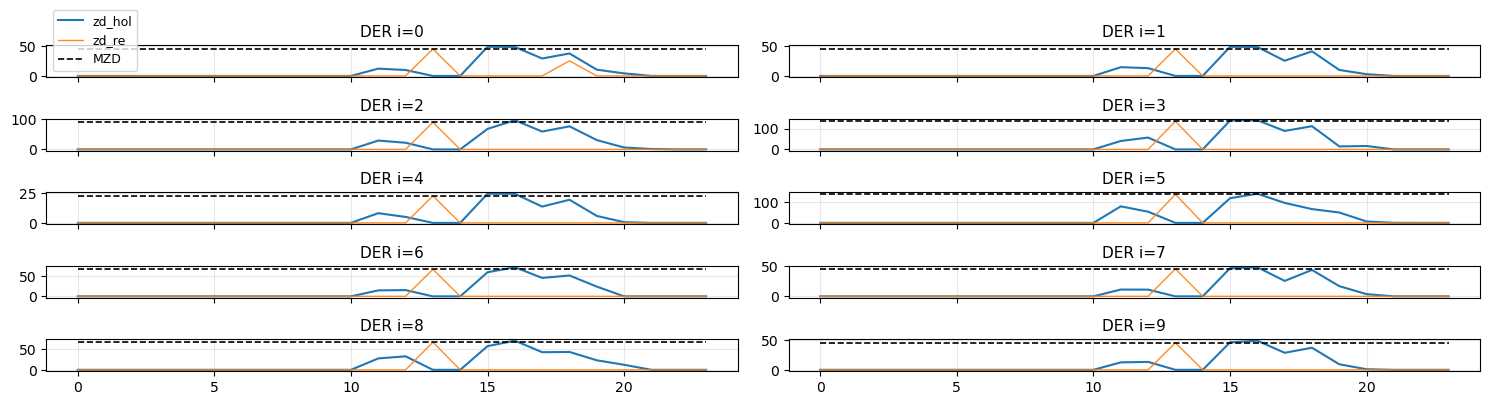

In [ ]:
scen = 0 

fig, axes = plt.subplots(5, 2, figsize=(15, 4), sharex=True)
axes = axes.flatten()

t_idx = np.arange(T)

for idx, i in enumerate(range(I)):
    ax = axes[idx]
    # ax.plot(t_idx, zd_ind[i, :, scen], linewidth=1, label='zd_ind', alpha=0.9)
    ax.plot(t_idx, zd_hol[i, :, scen], linewidth=1.5, label='zd_hol', alpha=1)
    ax.plot(t_idx, zd_re[i, :, scen], linewidth=1, label='zd_re', alpha=0.9)
    ax.plot(t_idx, MZD[i, :, scen], linestyle='--', color='black', linewidth=1.2, label='MZD')
    
    ax.set_title(f"DER i={i}", fontsize=11)
    ax.grid(True, alpha=0.3)

    if idx == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
print("="*50) ; print("AGGREGATOR LOSS ANALYSIS") ; print("="*50)
total_losses = []
for t in range(T):
    scenario_losses = []
    
    for s in range(S):
        total_supply = np.sum(dp_re[:, t, s])
        total_demand = np.sum(dm_re[:, t, s])
        lambda_price = -lambda_rep[t, s] * S
        
        loss = (total_demand - total_supply) * (lambda_price - P_RT[t, s])
        scenario_losses.append(loss)
    
    avg_loss = np.mean(scenario_losses)
    total_losses.append(avg_loss)
overall_avg_loss = np.mean(total_losses)
total_loss = np.sum(total_losses)
print("Individual Participation Profit", OBJ_IND)
print("Expected Replay Profit", OBJ_RE)
print(f"Total loss across all time periods: {total_loss:.2f}")
print("Realized Profit", OBJ_RE + total_loss)
print("Holistic Profit", OBJ_HOL)
print(); print("="*60) ; print("INDIVIDUAL PROFIT ANALYSIS") ; print("="*60)
profit_ind = np.zeros(I) ; profit_re = np.zeros(I) ; profit_hol = np.zeros(I) ; profit_re_adjusted = np.zeros(I)

price_weighted_usage = np.zeros(I)
for i, t, s in product(range(I), range(T), range(S)):
        lambda_price = -lambda_rep[t, s] * S
        dm_contribution = dm_re[i, t, s] * (lambda_price)
        dp_contribution = dp_re[i, t, s] * (lambda_price)
        price_weighted_usage[i] += dm_contribution + dp_contribution

total_price_weighted_usage = np.sum(price_weighted_usage)
print(f"Total price-weighted usage: {total_price_weighted_usage:.2f}")

for i in range(I):
    profit_ind[i] = 0
    for t in range(T):
        profit_ind[i] += P_DA[t] * x_ind[i, t]
        profit_ind[i] += np.mean([P_RT[t, s] * yp_ind[i, t, s] for s in range(S)])
        profit_ind[i] -= np.mean([P_PN[t, s] * ym_ind[i, t, s] for s in range(S)])
    
    profit_re[i] = 0
    for t in range(T):
        profit_re[i] += P_DA[t] * x_re[i, t]
        profit_re[i] += np.mean([P_RT[t, s] * yp_re[i, t, s] for s in range(S)])
        profit_re[i] -= np.mean([P_PN[t, s] * ym_re[i, t, s] for s in range(S)])
        lambda_price = -lambda_rep[t, :] * S
        profit_re[i] += np.mean([lambda_price[s] * dp_re[i, t, s] for s in range(S)])
        profit_re[i] -= np.mean([lambda_price[s] * dm_re[i, t, s] for s in range(S)])
    
    profit_hol[i] = 0
    for t in range(T):
        profit_hol[i] += P_DA[t] * x_hol[i, t]
        profit_hol[i] += np.mean([P_RT[t, s] * yp_hol[i, t, s] for s in range(S)])
        profit_hol[i] -= np.mean([P_PN[t, s] * ym_hol[i, t, s] for s in range(S)])
        lambda_price = -lambda_rep[t, :] * S
        profit_hol[i] += np.mean([lambda_price[s] * dp_hol[i, t, s] for s in range(S)])
        profit_hol[i] -= np.mean([lambda_price[s] * dm_hol[i, t, s] for s in range(S)])

loss_per_player = np.zeros(I)
for i in range(I):
    if total_price_weighted_usage > 0:
        loss_per_player[i] = total_loss * (price_weighted_usage[i] / total_price_weighted_usage)
    else:
        loss_per_player[i] = total_loss / I  # fallback to equal distribution
    profit_re_adjusted[i] = profit_re[i] + loss_per_player[i]

print(f"{'Player':<8} {'Individual':<12} {'Replay':<12} {'Re+Loss':<12} {'Holistic':<12} {'Price Weight':<12} {'Loss Share':<12} {'Re+Loss-Ind (%)':<22}") # 마지막 열 이름 및 간격 수정
print("-" * 125)

# 합계 계산을 위한 변수 초기화
total_ind = 0 ; total_re = 0 ; total_hol = 0 ; total_re_adj = 0

# 플레이어별 데이터 출력
for i in range(I):
    diff_adj_ind = profit_re_adjusted[i] - profit_ind[i]
    
    # --- 백분율 계산 로직 추가 ---
    # Individual 이익이 0이 아닐 경우에만 백분율 계산
    if profit_ind[i] != 0:
        percentage_change = (diff_adj_ind / profit_ind[i]) * 100
        # 포맷팅: 소수점 한 자리까지, 항상 부호(+) 표시
        final_column_str = f"{diff_adj_ind:<12.2f} ({percentage_change:+.1f}%)"
    else:
        # Individual 이익이 0일 경우 'N/A' 또는 'inf'로 표시
        final_column_str = f"{diff_adj_ind:<12.2f} (N/A)"
    # --- 여기까지 ---

    print(f"{i:<8} {profit_ind[i]:<12.2f} {profit_re[i]:<12.2f} {profit_re_adjusted[i]:<12.2f} {profit_hol[i]:<12.2f} {loss_per_player[i]:<12.2f} {final_column_str:<22}")
    
    # 합계 누적
    total_ind += profit_ind[i]
    total_re += profit_re[i]
    total_hol += profit_hol[i]
    total_re_adj += profit_re_adjusted[i]

# 전체 합계에 대한 차이 및 백분율 계산
total_diff_adj_ind = total_re_adj - total_ind
if total_ind != 0:
    total_percentage_change = (total_diff_adj_ind / total_ind) * 100
    total_final_column_str = f"{total_diff_adj_ind:<12.2f} ({total_percentage_change:+.1f}%)"
else:
    total_final_column_str = f"{total_diff_adj_ind:<12.2f} (N/A)"
    
print("-" * 125)
print(f"{'TOTAL':<8} {total_ind:<12.2f} {total_re:<12.2f} {total_re_adj:<12.2f} {total_hol:<12.2f} {np.sum(loss_per_player):<12.2f} {total_final_column_str:<22}")

# =======================================
# ⬇️ DataFrame으로 정리
# =======================================
results = []
for i in range(I):
    diff_adj_ind = profit_re_adjusted[i] - profit_ind[i]
    if profit_ind[i] != 0:
        percentage_change = (diff_adj_ind / profit_ind[i]) * 100
    else:
        percentage_change = np.nan  # 0 나눗셈 방지

    results.append({
        "Player": i,
        "Individual Profit": profit_ind[i],
        "Replay Profit": profit_re[i],
        "Replay + Loss": profit_re_adjusted[i],
        "Holistic Profit": profit_hol[i],
        "Loss Share": loss_per_player[i],
        "Replay+Loss - Individual": diff_adj_ind,
        "Change (%)": percentage_change
    })

results.append({
    "Player": "TOTAL",
    "Individual Profit": np.sum(profit_ind),
    "Replay Profit": np.sum(profit_re),
    "Replay + Loss": np.sum(profit_re_adjusted),
    "Holistic Profit": np.sum(profit_hol),
    "Loss Share": np.sum(loss_per_player),
    "Replay+Loss - Individual": np.sum(profit_re_adjusted) - np.sum(profit_ind),
    "Change (%)": (np.sum(profit_re_adjusted) - np.sum(profit_ind)) / np.sum(profit_ind) * 100 if np.sum(profit_ind) != 0 else np.nan
})

df_result = pd.DataFrame(results)

# =======================================
# ⬇️ CSV 저장 경로 설정
# =======================================
output_dir = r"C:\Users\jangseohyun\SynologyDrive\workspace\symply\DER\solution"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"profit_analysis_{SEED}.csv")

df_result.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"\n✅ 결과가 CSV로 저장되었습니다: {output_path}")

AGGREGATOR LOSS ANALYSIS
Individual Participation Profit 4371147.201376823
Expected Replay Profit 5213684.3314933
Total loss across all time periods: -2504560.35
Realized Profit 2709123.9797387403
Holistic Profit 5239402.093755724

INDIVIDUAL PROFIT ANALYSIS
Total price-weighted usage: 842000817.61
Player   Individual   Replay       Re+Loss      Holistic     Price Weight Loss Share   Re+Loss-Ind (%)       
-----------------------------------------------------------------------------------------------------------------------------
0        300692.30    356523.82    196068.26    356523.82    -160455.56   -104624.04   (-34.8%) 
1        354865.79    420881.50    235099.71    420881.50    -185781.79   -119766.09   (-33.7%) 
2        534185.85    641228.12    339222.91    641228.12    -302005.21   -194962.94   (-36.5%) 
3        796948.97    909417.14    455292.41    909417.14    -454124.74   -341656.56   (-42.9%) 
4        200053.72    262707.20    128979.00    262707.20    -133728.20   -7